[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap01/cap01_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

# Fundamentos e Primeiros Passos

Este capítulo inaugura a **Parte 1** do livro, focada nos fundamentos do Processamento Digital de Imagens (PDI). 
Aqui, você aprenderá como as imagens são representadas matematicamente e como manipulá-las 
usando Python e a biblioteca `morph.py` [@zampirolli2025morph].

## Objetivos

Ao final deste capítulo, você será capaz de:

- Compreender a natureza física e matemática da imagem digital $f(x,y)$.
- Identificar as faixas do espectro eletromagnético relevantes para PDI.
- Configurar o ambiente de desenvolvimento em Python.
- Realizar operações básicas: leitura, exibição e salvamento de imagens.
- Manipular estruturas de matrizes (NumPy) sem cair em armadilhas de memória.
- Acessar e modificar intensidades de pixels individualmente.
- Aplicar limiarização manual.

## Antes de começar: *Notebooks* em Python

Este material foi construído sob o conceito de ***Literate Programming*** (Programação Literária), idealizado por Donald Knuth na década de 84 [@knuth_literate_1984]. Knuth — também criador do sistema **TeX** para tipografia digital — propôs que os programas fossem escritos como uma narrativa lógica para seres humanos, intercalando código e documentação.

Para executar uma célula, pressione <kbd>Shift</kbd> + <kbd>Enter</kbd> ou clique no botão ▶️.

::: {.callout-note}
### Nota sobre o formato {.unnumbered}

Se você estiver lendo a versão renderizada (PDF ou HTML), o código aparecerá como blocos estáticos. Para interagir, acesse o link do **Google Colab** no topo da página.
:::

## Fundamentos

O estudo de sistemas baseados em imagens compreende um ecossistema de disciplinas integradas que transformam dados visuais brutos em conhecimento estruturado. Enquanto algumas áreas focam na geração de representações, outras dedicam-se ao tratamento e à análise desses dados para dar suporte a aplicações tecnológicas complexas.

O diagrama apresentado no @fig-1-representacao estabelece a distinção e complementaridade entre o Processamento de Imagens (PDI) e a Visão Computacional (VC). O PDI, destacado em **verde**, tem como foco a transformação de imagem para imagem, visando melhoria de qualidade ou pré-processamento, como a remoção de ruídos e realce de contraste.

Em contrapartida, a VC, assinalada em **azul**, foca na interpretação do conteúdo visual para extrair modelos ou informações, como o reconhecimento de objetos e gestos. A região de intersecção ilustra a sinergia entre as áreas, onde o PDI prepara os dados visuais para a interpretação pela VC. O mapa também demonstra as interconexões de ambas as disciplinas com áreas como Robótica, Computação Gráfica, Inteligência Artificial e Neurociência.

::: {#fig-1-representacao}

![](imagens/fig-1-pdf-vc.png){width=100% fig-align="center"}

Diagrama relacional detalhando as distinções fundamentais, sinergias e interconexões entre Processamento de Imagens e Visão Computacional no contexto de sistemas baseados em imagens.

:::

### 👁️ Visão Computacional

- **Foco:** *Imagem → Modelo* (caminho inverso da Computação Gráfica).  
- **Objetivo:** Extrair informação de alto nível a partir de imagens ou vídeos.  
- **Aplicações típicas:**
  - Robótica – detecção de obstáculos, localização e navegação autônoma.
  - Vigilância e inspeção – reconhecimento de eventos, leitura de placas, controle de qualidade.
  - Sensoriamento remoto – análise de imagens de satélite, mapeamento ambiental.
  - Imagens médicas – detecção de tumores, segmentação de órgãos, auxílio ao diagnóstico.
  - Interação humano‑computador – reconhecimento de gestos, expressões faciais, rastreamento ocular.
- **Relação com outras áreas:** utiliza técnicas de Aprendizado de Máquina e IA para classificar e interpretar cenas; serve como “olhos” da Robótica.

### 🖼️ Processamento Digital de Imagens (PDI)

- **Foco:** *Imagem → Imagem* (geralmente – transformação de uma imagem em outra).  
- **Objetivo:** Melhorar a qualidade visual ou extrair características de baixo nível.  
- **Aplicações comuns:**
  - Eliminação de ruídos (filtros de média, mediana, gaussiano).
  - Melhoria de contraste (equalização de histograma, ajuste gamma).
  - Detecção de bordas (Sobel, Canny, Laplaciano).
  - Segmentação (limiarização, crescimento de regiões, *watershed*).
  - Transformações geométricas (redimensionamento, rotação, correção de perspectiva).
- **Relação com outras áreas:**  
  - É a **base** para a maioria dos sistemas de Visão Computacional (pré‑processamento).  
  - A Computação Gráfica frequentemente aplica PDI para pós‑processamento (ex.: suavização, realce).  
  - Técnicas de IA podem otimizar parâmetros de processamento (ex.: aprendizado de filtros).


###  Como as “Outras Áreas” se conectam

| Área                      | Relação com PDI e VC                                                                 |
|---------------------------|--------------------------------------------------------------------------------------|
| **Inteligência Artificial** | Fornece modelos (redes neurais, SVM) que interpretam saídas da VC.                    |
| **Robótica**              | Consome dados de VC para tomar decisões (navegação, manipulação).                     |
| **Aprendizado de Máquina**| Usa descritores extraídos pelo PDI/VC para treinar classificadores.                   |
| **Computação Gráfica**    | Caminho inverso: *modelo → imagem*; muitas vezes aplica PDI para renderização realista. |
| **Neurociência**          | Inspira modelos de PDI (ex.: filtros semelhantes a células ganglionares da retina).   |

## Etapas do PDI

As etapas do PDI são apresentadas na @fig-1-etapas, que podem ser compreendidas como uma cadeia de transformações que reduz a redundância dos dados em busca de significado:

*   **Baixo Nível:** Atua diretamente sobre os pixels da imagem ruidosa para realizar melhorias e filtragens, gerando como saída uma imagem limpa ou realçada.
*   **Médio Nível:** Recebe a imagem tratada e realiza a segmentação e descrição, transformando a matriz de pixels em atributos estruturados (forma, tamanho e textura).
*   **Alto Nível:** Utiliza a tabela de atributos para alimentar processos de lógica e inteligência artificial, resultando na decisão ou reconhecimento final (como o diagnóstico médico).

::: {#fig-1-etapas}

![](imagens/fig-1-etapas.png){width=100% fig-align="center"}

Representação do fluxo sequencial de processamento: a saída de cada nível torna-se a entrada do nível subsequente.
:::

Detalhando mais essas etapas, a @fig-1-etapas2 ilustra a jornada completa da informação visual, desde a sua captura até a interpretação final. O fluxo inicia-se na **Aquisição da Imagem (1)** e avança por processos de tratamento como o **Melhoramento (2)** e a **Restauração (3)**. Em seguida, o conteúdo é isolado através da **Segmentação (4)** e refinado pela **Morfologia (5)**. O estágio crucial de transição ocorre na **Representação e Descrição (6)**, onde objetos visuais são convertidos em dados matemáticos (como área e perímetro), permitindo que o sistema execute o **Reconhecimento do Objeto (7)**. Este ecossistema é suportado por pilares como o **Processamento de Imagem Colorida** e a **Compressão**, que garantem a eficiência no armazenamento e análise dos dados.

::: {#fig-1-etapas2}

![](imagens/fig-1-etapas2.png){width=100% fig-align="center"}

Fluxo detalhado do PDI: da aquisição sensorial à extração de atributos e reconhecimento automatizado, incluindo em processamento colorido e compressão.
:::

## Formação da Imagem e o Espectro

O processo de formação de uma imagem é fundamentado na interação entre a matéria e a energia radiante. Essencialmente, uma imagem é concebida quando um **sensor registra a radiação** resultante da interação com um objeto físico. No contexto da visão humana e da fotografia convencional, este fenômeno depende de uma fonte de luz que ilumine a cena; as características dos objetos são então codificadas através das **variações de intensidade e cor** da luz que atinge o sensor, conforme ilustrado na @fig-1-luz.

::: {#fig-1-luz}

![](imagens/fig-1-luz.png){width=100% fig-align="center"}

Representação do espectro visível e sua posição em relação às demais radiações eletromagnéticas, destacando a variação dos comprimentos de onda de 380 nm a 750 nm.
:::

A **luz visível** ocupa apenas uma pequena faixa do espectro eletromagnético — entre **380 nm (violeta)** e **750 nm (vermelho)** —, conforme ilustrado na @fig-1-espectro. Sensores digitais convencionais operam nessa mesma janela, mas equipamentos especializados podem captar radiações invisíveis ao olho humano, como o infravermelho e os raios X. Em PDI, a imagem formada depende diretamente da sensibilidade espectral do sensor utilizado.

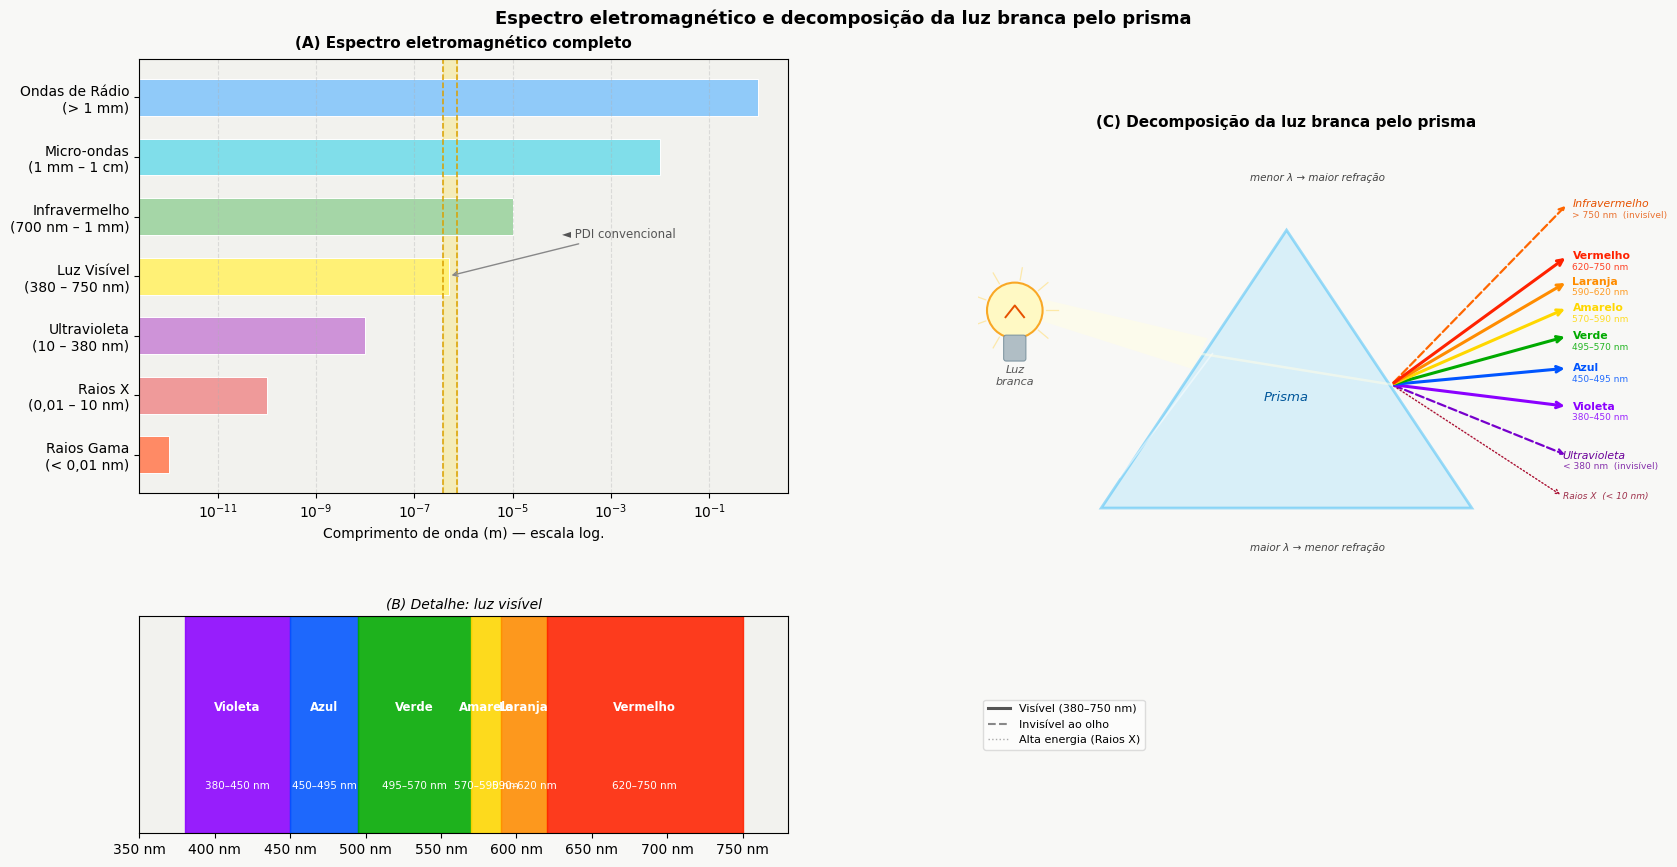

In [ ]:
#| label: fig-1-espectro
#| fig-cap: "(A) Espectro eletromagnético completo em escala logarítmica, com destaque para a faixa visível. (B) Detalhe da luz visível (380–750 nm) e suas cores componentes. (C) Decomposição da luz branca pelo prisma: menor comprimento de onda sofre maior refração, separando UV, visível e infravermelho."
#| echo: false
#| output: true
#| fig-width: 16
#| fig-height: 9

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon

# ═══════════════════════════════════════════════════════════════════
# Dados
# ═══════════════════════════════════════════════════════════════════
faixas = [
    'Ondas de Rádio\n(> 1 mm)',
    'Micro-ondas\n(1 mm – 1 cm)',
    'Infravermelho\n(700 nm – 1 mm)',
    'Luz Visível\n(380 – 750 nm)',
    'Ultravioleta\n(10 – 380 nm)',
    'Raios X\n(0,01 – 10 nm)',
    'Raios Gama\n(< 0,01 nm)',
]
comprimentos_rep = [1e0, 1e-2, 1e-5, 5e-7, 1e-8, 1e-10, 1e-12]
cores_barras     = ['#90CAF9', '#80DEEA', '#A5D6A7', '#FFF176',
                    '#CE93D8', '#EF9A9A', '#FF8A65']

limites_nm = [380, 450, 495, 570, 590, 620, 750]
nomes_vis  = ['Violeta', 'Azul', 'Verde', 'Amarelo', 'Laranja', 'Vermelho']
cores_vis  = ['#8B00FF', '#0055FF', '#00AA00', '#FFD700', '#FF8C00', '#FF2200']
lim_vis_m  = np.array(limites_nm) * 1e-9

# ═══════════════════════════════════════════════════════════════════
# Ângulos unificados: leque proporcional do Raios X ao Infravermelho
#
#  10 posições uniformes de 50° (mais refratado) a -16° (menos refratado)
#  Índices:  0=RaiosX  1=UV  2..7=visíveis(violeta→vermelho)  9=IV
# ═══════════════════════════════════════════════════════════════════
angulos_todos = np.linspace(56, -18, 10)  # graus, mais refratado → menos

ang_xray = angulos_todos[0]   # Raios X
ang_uv   = angulos_todos[1]   # Ultravioleta
angulos_vis = angulos_todos[2:8]  # 6 cores visíveis (violeta→vermelho)
ang_iv   = angulos_todos[9]   # Infravermelho

# ═══════════════════════════════════════════════════════════════════
# Layout
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 9), facecolor='#F8F8F6')
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.05, 1],
    height_ratios=[2.8, 1.4],
    hspace=0.38, wspace=0.30,
    left=0.06, right=0.97, top=0.93, bottom=0.07,
)
ax_spec  = fig.add_subplot(gs[0, 0])
ax_vis   = fig.add_subplot(gs[1, 0])
ax_prism = fig.add_subplot(gs[:, 1])

for ax in (ax_spec, ax_vis, ax_prism):
    ax.set_facecolor('#F2F2EE')

# ═══════════════════════════════════════════════════════════════════
# Painel A – Espectro completo
# ═══════════════════════════════════════════════════════════════════
ax_spec.barh(faixas, comprimentos_rep,
             color=cores_barras, edgecolor='white', linewidth=0.7, height=0.62)
ax_spec.set_xscale('log')
ax_spec.set_xlabel('Comprimento de onda (m) — escala log.', fontsize=10)
ax_spec.set_title('(A) Espectro eletromagnético completo',
                  fontsize=11, fontweight='bold', pad=8)
ax_spec.invert_yaxis()
ax_spec.grid(axis='x', which='both', linestyle='--', alpha=0.35)
ax_spec.axvspan(380e-9, 750e-9, color='#FFD700', alpha=0.22, zorder=0)
ax_spec.axvline(380e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
ax_spec.axvline(750e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
idx_vis = faixas.index('Luz Visível\n(380 – 750 nm)')
ax_spec.annotate(
    '◄ PDI convencional',
    xy=(5e-7, idx_vis), xytext=(1e-4, idx_vis - 0.65),
    fontsize=8.5, color='#555',
    arrowprops=dict(arrowstyle='->', color='#888', lw=1.0),
)

# ═══════════════════════════════════════════════════════════════════
# Painel B – Detalhe da luz visível
# ═══════════════════════════════════════════════════════════════════
ax_vis.set_xlim(350e-9, 780e-9)
ax_vis.set_ylim(0, 1)
for i, nome in enumerate(nomes_vis):
    xi, xf = lim_vis_m[i], lim_vis_m[i + 1]
    cx = (xi + xf) / 2
    ax_vis.axvspan(xi, xf, color=cores_vis[i], alpha=0.88)
    ax_vis.text(cx, 0.58, nome,
                ha='center', va='center', fontsize=8.5,
                fontweight='bold', color='white')
    ax_vis.text(cx, 0.22, f'{limites_nm[i]}–{limites_nm[i+1]} nm',
                ha='center', va='center', fontsize=7.5, color='white')
ax_vis.set_yticks([])
ax_vis.set_title('(B) Detalhe: luz visível',
                 fontsize=10, style='italic', pad=5)
ax_vis.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x*1e9:.0f} nm')
)

# ═══════════════════════════════════════════════════════════════════
# Painel C – Prisma
# ═══════════════════════════════════════════════════════════════════
ax_prism.set_xlim(0, 10)
ax_prism.set_ylim(0, 10)
ax_prism.set_aspect('equal')
ax_prism.axis('off')
ax_prism.set_title('(C) Decomposição da luz branca pelo prisma',
                   fontsize=11, fontweight='bold', pad=8)

# Vértices do prisma
px_esq, py_esq = 2.0, 4.0
px_dir, py_dir = 8.0, 4.0
px_top, py_top = 5.0, 8.5

prism_pts = np.array([[px_esq, py_esq], [px_dir, py_dir], [px_top, py_top]])
ax_prism.add_patch(Polygon(prism_pts, closed=True,
                            fc='#B3E5FC', ec='#29B6F6', lw=2.0,
                            alpha=0.45, zorder=5))
ax_prism.plot([2.3, 3.8], [4.5, 6.5], color='white', lw=1.2, alpha=0.5, zorder=6)
ax_prism.text(5.0, 5.8, 'Prisma',
              ha='center', va='center', fontsize=9.5,
              color='#01579B', style='italic', zorder=7)

# ── Lâmpada ──────────────────────────────────────────────────────
lx, ly = 0.6, 7.2
ax_prism.add_patch(plt.Circle((lx, ly), 0.45,
                               color='#FFF9C4', ec='#F9A825', lw=1.5, zorder=8))
ax_prism.plot([lx - 0.15, lx, lx + 0.15],
              [ly - 0.11, ly + 0.08, ly - 0.11],
              color='#E65100', lw=1.4, zorder=9)
for ang in np.linspace(0, 360, 9, endpoint=False):
    r0, r1 = 0.50, 0.70
    ax_prism.plot(
        [np.cos(np.radians(ang)) * r0 + lx,
         np.cos(np.radians(ang)) * r1 + lx],
        [np.sin(np.radians(ang)) * r0 + ly,
         np.sin(np.radians(ang)) * r1 + ly],
        color='#FFE082', lw=0.9, alpha=0.65, zorder=7,
    )
ax_prism.add_patch(mpatches.FancyBboxPatch(
    (lx - 0.14, ly - 0.78), 0.28, 0.34,
    boxstyle='round,pad=0.04', fc='#B0BEC5', ec='#78909C', lw=0.7, zorder=8,
))
ax_prism.text(lx, ly - 1.2, 'Luz\nbranca',
              ha='center', fontsize=8, color='#555', style='italic')

# ── Feixe branco → prisma ────────────────────────────────────────
inc_x, inc_y = 3.6, 6.5
beam = np.array([
    [lx + 0.46, ly + 0.18],
    [lx + 0.46, ly - 0.18],
    [inc_x - 0.12, inc_y - 0.25],
    [inc_x + 0.12, inc_y + 0.25],
])
ax_prism.add_patch(Polygon(beam, closed=True,
                            fc='#FFFDE7', ec='none', alpha=0.65, zorder=4))

# Ponto de saída (face direita do prisma)
out_x, out_y = 6.7, 6.0
ax_prism.plot([inc_x, out_x], [inc_y, out_y],
              color='#FFFDE7', lw=1.8, alpha=0.55, zorder=6)

# ── Função auxiliar: calcula yf a partir de ângulo ───────────────
def yf_at(x_dest, ang_deg):
    dx = x_dest - out_x
    return out_y - dx * np.tan(np.radians(ang_deg)) + 2

# ── Raios visíveis ───────────────────────────────────────────────
x_fim = 9.55
for i, (nome, cor, ang) in enumerate(zip(nomes_vis, cores_vis, angulos_vis)):
    yf = yf_at(x_fim, ang)
    ax_prism.annotate(
        '', xy=(x_fim, yf), xytext=(out_x, out_y),
        arrowprops=dict(arrowstyle='->', color=cor, lw=2.2, mutation_scale=10),
        zorder=4,
    )
    ax_prism.text(x_fim + 0.08, yf,
                  nome, va='center', fontsize=7.8, color=cor, fontweight='bold')
    ax_prism.text(x_fim + 0.08, yf - 0.18,
                  f'{limites_nm[i]}–{limites_nm[i+1]} nm',
                  va='center', fontsize=6.5, color=cor, alpha=0.85)

# ── Ultravioleta ─────────────────────────────────────────────────
yf_uv = yf_at(x_fim, ang_uv) -0.01
ax_prism.annotate(
    '', xy=(x_fim, yf_uv), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#7700CC',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(x_fim -0.08 , yf_uv,
              'Ultravioleta', va='center', fontsize=7.8,
              color='#6A0099', style='italic')
ax_prism.text(x_fim -0.08 , yf_uv - 0.18,
              '< 380 nm  (invisível)', va='center',
              fontsize=6.5, color='#6A0099', alpha=0.8)

# ── Raios X ──────────────────────────────────────────────────────
yf_xr = yf_at(x_fim - 0.08, ang_xray) +0.3
ax_prism.annotate(
    '', xy=(x_fim - 0.08, yf_xr), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#AA1133',
                    lw=1.0, linestyle='dotted', mutation_scale=8),
    zorder=2,
)
ax_prism.text(x_fim - 0.08, yf_xr,
              'Raios X  (< 10 nm)', va='center',
              fontsize=6.5, color='#880022', style='italic', alpha=0.8)

# ── Infravermelho ─────────────────────────────────────────────────
yf_iv = yf_at(x_fim, ang_iv)
ax_prism.annotate(
    '', xy=(x_fim, yf_iv), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#FF6600',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(x_fim + 0.08, yf_iv,
              'Infravermelho', va='center', fontsize=7.8,
              color='#E65100', style='italic')
ax_prism.text(x_fim + 0.08, yf_iv - 0.18,
              '> 750 nm  (invisível)', va='center',
              fontsize=6.5, color='#E65100', alpha=0.8)

# ── Anotações de refração ─────────────────────────────────────────
ax_prism.text(5.5, 9.3, 'menor λ → maior refração',
              ha='center', fontsize=7.5, color='#444', style='italic')
ax_prism.text(5.5, 3.3, 'maior λ → menor refração',
              ha='center', fontsize=7.5, color='#444', style='italic')

# ── Legenda ──────────────────────────────────────────────────────
ax_prism.plot([], [], color='#555', lw=2.2,          label='Visível (380–750 nm)')
ax_prism.plot([], [], color='#888', lw=1.5, ls='--', label='Invisível ao olho')
ax_prism.plot([], [], color='#AAA', lw=1.0, ls=':',  label='Alta energia (Raios X)')
ax_prism.legend(loc='lower left', fontsize=8,
                framealpha=0.65, edgecolor='#CCCCCC')

# ═══════════════════════════════════════════════════════════════════
plt.suptitle(
    'Espectro eletromagnético e decomposição da luz branca pelo prisma',
    fontsize=13, fontweight='bold', y=0.985,
)
plt.show()

## O que é uma Imagem Digital?

Uma **imagem digital** é formada por uma grade de **pixels** (*Picture Elements*), onde cada pixel é a menor unidade elementar da imagem.

::: {.callout-tip}
### O que é um Pixel?
Um **pixel** é a menor unidade que compõe uma imagem digital. Cada pixel ocupa uma posição única na grade e armazena um ou mais valores numéricos que representam sua intensidade ou cor.
:::

### Representação Matemática {.unnumbered}

Diferente de uma função contínua, o domínio de uma imagem digital é um plano retangular finito $\mathbb{E} \subset \mathbb{Z}^2$, que representa a grade de amostragem. Este domínio é indexado por coordenadas inteiras:

$$
\mathbb{E}  = \{ (x, y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H \}
$$ {#eq-1-dominio}

Onde:

*   **$L$**: representa a largura da imagem (número de colunas).
*   **$H$**: representa a altura da imagem (número de linhas).

A imagem digital é uma função que associa cada par de coordenadas $(x,y)$ a um ou mais valores que descrevem a aparência do pixel. 

$$
f: \mathbb{E}  \to \mathcal{V}
$$ {#eq-1-image}

O conjunto $\mathcal{V}$ define os valores possíveis para o pixel (codomínio), variando conforme o tipo de imagem, como demonstrado na @tbl-1-tipos-imagem.

| Tipo de imagem | $\mathcal{V}$ (valores do pixel) | Representação |
|:---|:---|:---:|
| **Binária** | $\{0, 1\}$ ou $\{0, 255\}$ | ⬛◻️ |
| **Tons de cinza** | $\{0, 1, \dots, 255\}$ | ░▒▓█ |
| **Colorida (RGB)** | $\{0, \dots, 255\}^3$ (triplas) | 🟥🟩🟦 |

: Principais tipos de imagem digital e seus respectivos conjuntos de valores possíveis para cada pixel. {#tbl-1-tipos-imagem}

**Exemplo prático:** Uma imagem colorida (RGB) é representada matematicamente por uma função que retorna três valores para cada pixel. No computador, isso resulta em três matrizes sobrepostas (canais R, G e B), onde cada célula contém um valor de intensidade para aquele canal específico no pixel.

## Configuração do Ambiente

Utilizaremos o ecossistema científico do Python, com destaque para o **NumPy** (matemática matricial), **OpenCV** (visão computacional padrão de mercado) e a biblioteca **morph.py** [@zampirolli2025morph], desenvolvida especificamente para fins didáticos neste livro.

### 📦 Bibliotecas utilizadas

| Biblioteca | Função principal |
|:-----------|:-----------------|
| `numpy` | Representação matricial de imagens |
| `opencv-python` | Leitura, escrita e operações de visão computacional |
| `matplotlib` | Visualização de imagens e gráficos |
| `morph.py` | Abstração didática das operações de PDI |

::: {.callout-note}
## Versões do `morph.py`

A biblioteca `morph.py` possui duas versões públicas:

- **Versão 1.0** — versão original, publicada junto ao artigo apresentado no EduComp2024:
  <https://github.com/fzampirolli/morph>

- **Versão 1.1** — versão compacta, utilizada nas atividades deste livro:
  <https://github.com/fzampirolli/pdi-vc/blob/master/morph/morph.py>

A versão 1.1 foi necessária para uso nas atividades do **Moodle/VPL** (Laboratório Virtual de Programação). Na versão 1.0, bibliotecas como `matplotlib`, `requests` e `skimage` são carregadas no momento do `import morph`, o que causava erro de memória (`Jail: out of memory, 128MiB`) no ambiente restrito do VPL.

Na versão 1.1, esses imports foram convertidos para **carregamento lazy**: cada biblioteca é importada apenas dentro do método que a utiliza, e somente quando esse método é de fato chamado. Assim, um simples `import morph` carrega apenas `numpy` e `cv2`, que são suficientes para a maioria dos exercícios práticos.
:::

In [ ]:
#| quarto-raw: true

import os, importlib, urllib.request

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

# Correção: Verifica se o atributo existe antes de imprimir, 
# ou simplesmente confirma o carregamento do módulo.
version = getattr(morph, "__version__", "local_file")
print(f"✅ Ambiente pronto. Módulo 'morph' carregado com sucesso.")
print(f"📦 Funções disponíveis no mm: {dir(mm)[-5:]}...") # Mostra as últimas funções para confirmar

✅ Ambiente pronto. Módulo 'morph' carregado com sucesso.
📦 Funções disponíveis no mm: ['union', 'verifyBoundBox', 'water0', 'waterB', 'watershed']...


## Fundamentos de Matrizes (Cuidado!)

Como uma imagem digital é uma matriz, precisamos saber criá-las corretamente. Em Python, existe uma armadilha comum ao usar o operador * em listas:

::: {.callout-warning}

### Atenção à cópia de referências {.unnumbered}

Ao fazer `m = [[0]*2]*3`, você não cria 3 linhas independentes, mas sim 3 referências para a **mesma** linha. Alterar um valor em uma linha alterará todas as outras!
:::

Para visualizar esse comportamento, você pode testar o código no [Python Tutor](https://pythontutor.com/) e comparar com a forma correta de criar matriz com listas: `m = [[0]*2 for _ in range(3)]`.

A forma recomendada e padrão em Processamento Digital de Imagens é usar **NumPy**, que cria matrizes com dados independentes e oferece eficiência computacional. O código a seguir mostra diferentes formas de criação de imagens sintéticas — o resultado é exibido na @fig-imagens-sinteticas.



Matriz Aleatória Gerada:
138 151  52 128  13 137 
189  69 156 106  77 223 
194 165  49  82 178 226 
217 173 220 164 224 191 



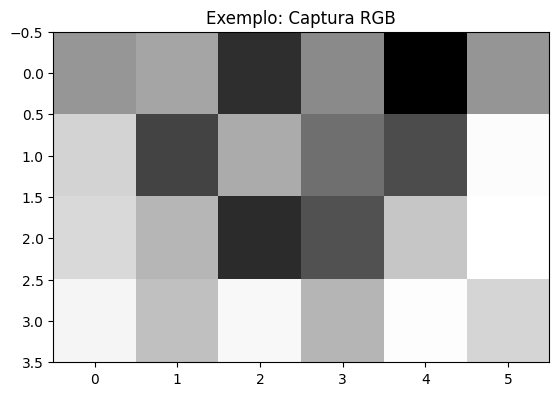

In [ ]:
#| quarto-raw: false
#| label: fig-imagens-sinteticas
#| fig-cap: "Exemplo de imagem sintética gerada por matriz aleatória 4x6."
#| echo: true
#| output: true

# Criando uma imagem preta (zeros) de 5x5 pixels
img_preta = np.zeros((5, 5), dtype='uint8')

# Criando uma imagem branca (255) de 5x5 pixels
img_branca = np.ones((5, 5), dtype='uint8') * 255

# Criando uma imagem aleatória para testes (Ruído)
img_random = mm.randomImage(4, 6, maxValue=255)

print("Matriz Aleatória Gerada:")
print(mm.drawImage(img_random))

mm.show(img_random, title="Exemplo: Captura RGB")

## Lendo e Exibindo Imagens

Em Python, as imagens são lidas como *arrays* do NumPy. Isso significa que toda a potência da álgebra linear está disponível para o processamento de imagens.

A operação mais básica em PDI é a leitura de uma imagem.
A função `mm.read()` da `morph.py` aceita caminhos locais e URLs, ver o resultado na @fig-1-lena.


Dimensões (H, W, Canais): (512, 512, 3)
Tipo de dado: uint8


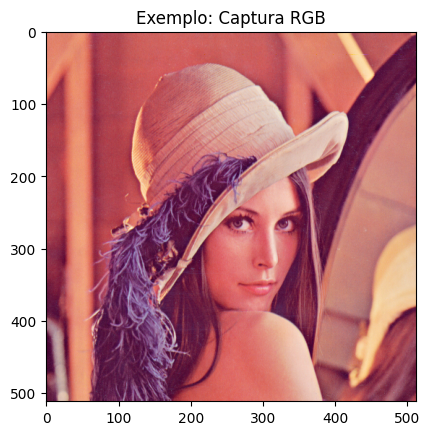

In [ ]:
#| quarto-raw: false
#| label: fig-1-lena
#| fig-cap: "Imagem clássica de processamento de imagens: 'Lena'."
#| echo: true
#| output: true

# Carregando uma imagem de exemplo via URL
url = "https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png"
img = mm.read(url)

# Exibindo informações básicas
print(f"Dimensões (H, W, Canais): {img.shape}")
print(f"Tipo de dado: {img.dtype}")

# Exibição estética
mm.show(img, title="Exemplo: Captura RGB")

### Alternativa: Baixando a imagem localmente {.unnumbered}

Se por algum motivo a leitura direta da URL não funcionar (firewall, restrições de rede, ou se você preferir trabalhar com arquivos locais), uma abordagem simples é **baixar a imagem** usando o comando `wget` (disponível em ambientes Linux, macOS e no Google Colab) e depois carregá-la com `mm.read()` a partir do arquivo salvo.

```bash
!wget -O lena.png https://upload.wikimedia.org/wikipedia/en/7/7d/Lenna_%28test_image%29.png
```

```python
img = mm.read('lena.png')
mm.show(img, title="Exemplo: Captura RGB (arquivo local)")
```

#### Explicação: {.unnumbered}
- `!wget -O lena.png <URL>` baixa a imagem da Wikimedia e a salva com o nome `lena.png`.
- `mm.read('lena.png')` lê o arquivo local (sem necessidade de cabeçalhos HTTP ou tratamento especial).
- Essa estratégia é útil quando você quer **evitar dependências de rede** durante a execução ou **reutilizar a mesma imagem** várias vezes sem novo download.


::: {.callout-tip}
#### Nota {.unnumbered}
O prefixo `!` funciona no Jupyter Notebook, JupyterLab e Google Colab. Em um terminal comum, basta remover o `!`. Se o `wget` não estiver instalado, instale-o com `apt install wget` (Linux) ou use `curl -o lena.png <URL>` como alternativa.
:::

## Conversão de Tipos e Limiarização

Conforme vimos, uma imagem colorida no espaço RGB é representada pela função:

$$
f: \mathbb{E} \to \{0,1,\dots,255\}^3
$$

Ou seja, para cada pixel $(x,y)$, temos três valores $(R,G,B)$ que definem sua cor.

### Conversão para Tons de Cinza {.unnumbered}

Para converter uma imagem RGB em tons de cinza (*grayscale*), é necessário combinar os três canais em um único valor de intensidade $g$, que representa o brilho percebido. Como o olho humano não é igualmente sensível ao vermelho, verde e azul, utiliza-se uma **média ponderada**. O padrão [ITU-R BT.601](https://www.itu.int/rec/R-REC-BT.601/) [@itu_bt601] define os seguintes pesos:

$$
g = 0.299\,R + 0.587\,G + 0.114\,B 
$$ {#eq-1-cinza}

Após o cálculo, o valor $g$ é arredondado para o inteiro mais próximo e ajustado ao intervalo $[0, 255]$. O resultado é uma nova imagem, agora em tons de cinza, representada por:

$$
f_{\text{cinza}}: \mathbb{E} \to \{0,1,\dots,255\}
$$

### Limiarização (*Thresholding*) {.unnumbered}

A partir da imagem em tons de cinza $f_{\text{cinza}}(x,y)$, uma operação fundamental é a **limiarização**, que produz uma imagem **binária** (apenas preto e branco). Para isso, escolhe-se um valor de corte $T$ (geralmente no intervalo $[0,255]$) e define-se:

$$
f_{\text{bin}}(x,y) = 
\begin{cases} 
255 & \text{se } f_{\text{cinza}}(x,y) > T \\[4pt]
0 & \text{caso contrário}
\end{cases}
$$ {#eq-1-limiar}

**Exemplo:** Com $T = 128$, pixels com intensidade acima de 128 tornam-se brancos (255); os demais tornam-se pretos (0).

A limiarização é amplamente usada para **segmentar objetos do fundo**, extrair bordas ou criar máscaras binárias para processamento posterior. 

> **Nota:** O valor 255 representa o branco máximo em imagens de 8 bits, enquanto 0 representa o preto absoluto.

### Exemplo prático de conversão e limiarização {.unnumbered}

A @fig-1-processamento-basico ilustra os principais passos para transformar uma imagem colorida em tons de cinza e, em seguida, binarizá‑la por limiarização.
O código a seguir implementa essas etapas:

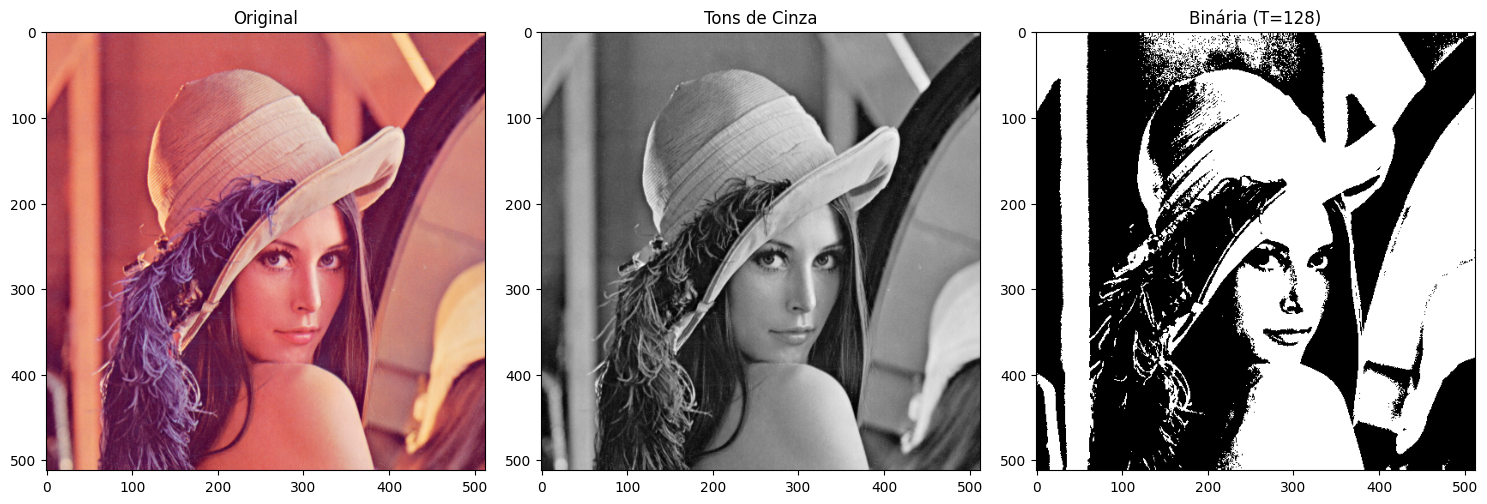

In [ ]:
#| quarto-raw: false
#| label: fig-1-processamento-basico
#| fig-cap: "Processamento básico de imagens: (a) imagem original, (b) imagem em tons de cinza, (c) imagem binarizada por limiar (T=128)."
#| echo: true
#| output: true

import matplotlib.pyplot as plt

# 1. Converter para Tons de Cinza
img_gray = mm.gray(img)

# 2. Aplicar limiar (Pixels > 128 tornam-se 255, outros 0)
limiar = 128
img_binaria = mm.threshold(img_gray, limiar)

# Uso da nova função
mm.show(
    [img, img_gray, img_binaria], 
    titles=["Original", "Tons de Cinza", f"Binária (T={limiar})"],
    cols=3
)

## Limiarização pelo método de Otsu

Conforme apresentado na @eq-1-limiar, a limiarização converte uma imagem em tons de cinza para binária usando um valor de corte $T$. Até agora fixamos $T = 128$ manualmente.

```python
img_bin_fixo = mm.threshold(img_gray, T=128)
```

Entretanto, a escolha manual de $T$ nem sempre é trivial. A biblioteca `mm` oferece uma alternativa automática: quando o parâmetro `limiar` **não é fornecido**, a função `mm.threshold(img_gray)` calcula o valor de $T$ pelo **método de Otsu** [@otsu1979]. Esse método, que será detalhado em capítulos futuros, maximiza a variância inter‑classes do histograma, separando automaticamente os pixels de objeto e fundo.

O código abaixo compara a limiarização manual ($T=128$) com a automática (Otsu), mostrando também o valor de $T$ calculado:

Limiar calculado por Otsu: T = 117.0


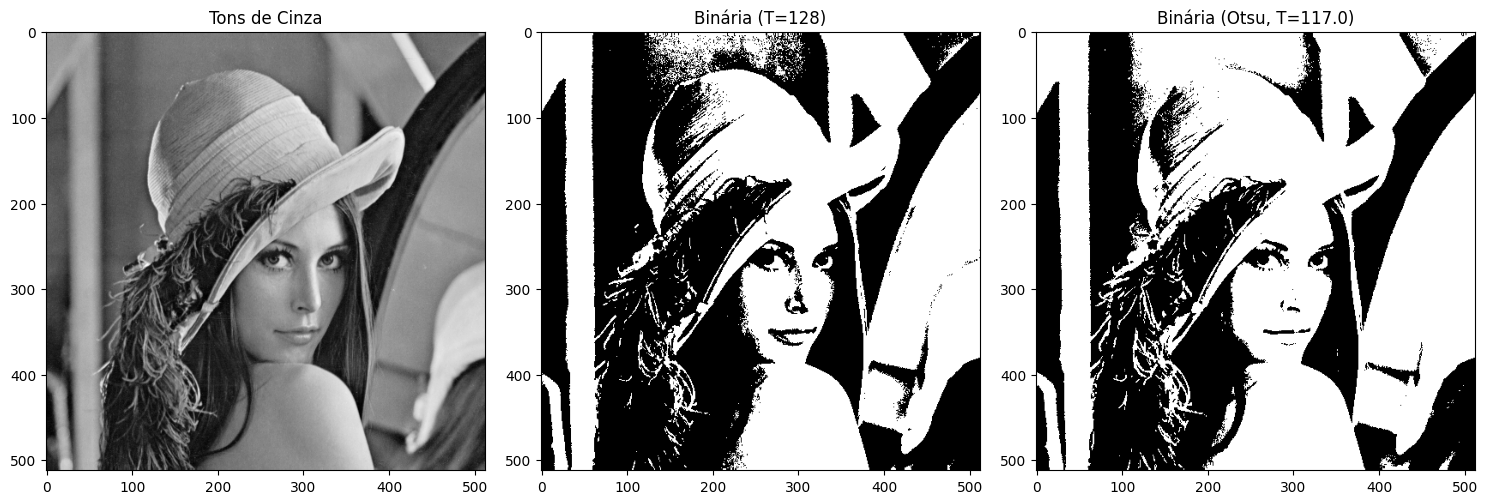

In [ ]:
#| quarto-raw: false
#| label: fig-1-otsu
#| fig-cap: "Comparação entre limiarização manual (T=128) e automática (Otsu) sobre a imagem em tons de cinza."
#| echo: true
#| output: true

import cv2
# Limiarização com T fixo (manual)
T_fixo = 128
img_bin_fixo = mm.threshold(img_gray, T_fixo)

# Limiarização pelo método de Otsu (T automático)
T_otsu, img_bin_otsu = cv2.threshold(img_gray, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar calculado por Otsu: T = {T_otsu}')
# ou simplesmente:
# img_bin_otsu = mm.threshold(img_gray)

# Exibição lado a lado
mm.show(
    [img_gray, img_bin_fixo, img_bin_otsu], 
    titles=["Tons de Cinza", f"Binária (T={T_fixo})", f"Binária (Otsu, T={T_otsu})"],
    cols=3
)

A @fig-1-otsu mostra que o limiar obtido por Otsu se adapta automaticamente à imagem, resultando em uma binarização mais eficiente do que um valor fixo, especialmente quando as intensidades do objeto e do fundo são bem separadas no histograma. Essa técnica é amplamente utilizada em sistemas de visão computacional para binarização de documentos, detecção de objetos e pré‑processamento de imagens.

::: {.callout-tip}
### Simplicidade da biblioteca `morph.py` {.unnumbered}

Enquanto o OpenCV exige a chamada completa:

```python
T_otsu, img_bin = cv2.threshold(img_gray, 0, 255,
                                cv2.THRESH_BINARY + cv2.THRESH_OTSU)
```

a biblioteca `mm` abstrai toda essa complexidade: basta chamar `mm.threshold(img_gray)`. O limiar de Otsu é calculado automaticamente e a imagem binária é retornada diretamente. Essa abordagem permite que você se concentre no conceito, não nos detalhes de implementação.
:::

## Acesso a Pixels

Em Python com NumPy, uma imagem é representada como um **array multidimensional**. Para acessar um pixel específico, utilizam-se as coordenadas **linha** (eixo Y) e **coluna** (eixo X): `img[linha, coluna]`.  

O código abaixo demonstra como obter o valor de um pixel em uma imagem RGB e em sua versão em tons de cinza, além de criar uma pequena imagem sintética para visualizar a estrutura de uma matriz de pixels.

Pixel na posição (100,100):
  - Tons de cinza : 102
  - RGB           : R=178, G=68, B=78

Matriz da imagem sintética 5×5:
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0 255   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


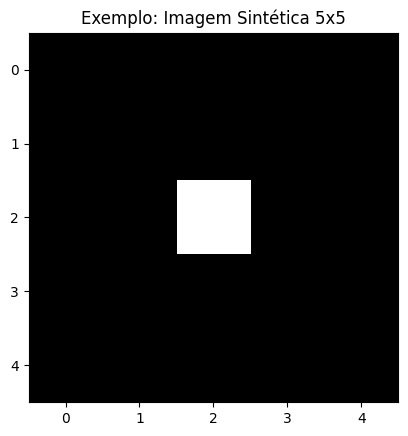

In [ ]:
#| quarto-raw: false
#| label: fig-1-pixel-acesso
#| fig-cap: "Exemplo de acesso a pixels: (a) imagem original com pixel destacado, (b) imagem em tons de cinza, (c) matriz sintética 5×5 com pixel central branco."
#| echo: true
#| output: true

import numpy as np
import matplotlib.pyplot as plt

# Coordenadas do pixel que queremos examinar
r, c = 100, 100

# Acessa o pixel na imagem em tons de cinza (um valor escalar)
pixel_cinza = img_gray[r, c]

# Acessa o pixel na imagem colorida RGB (vetor de 3 valores)
pixel_rgb = img[r, c]

print(f'Pixel na posição ({r},{c}):')
print(f'  - Tons de cinza : {pixel_cinza}')
print(f'  - RGB           : R={pixel_rgb[0]}, G={pixel_rgb[1]}, B={pixel_rgb[2]}')

# Cria uma imagem sintética 5×5 com todos os pixels pretos (0)
syn = np.zeros((5, 5), dtype=np.uint8)
# Torna o pixel central (linha 2, coluna 2) branco (255)
syn[2, 2] = 255

print("\nMatriz da imagem sintética 5×5:")
print(syn)

# Exibe a imagem sintética
# plt.figure(figsize=(3, 3))
# plt.imshow(syn, cmap='gray', vmin=0, vmax=255)
# plt.title("Imagem sintética 5×5\n(pixel central branco)")
# plt.axis('off')
# plt.tight_layout()
# plt.show()
# ou simplesmente:

mm.show(syn, title="Exemplo: Imagem Sintética 5x5")



**Explicação linha a linha:**

1. `img_gray[r, c]` – retorna um único número inteiro entre 0 e 255, correspondente ao nível de cinza naquela posição.  
2. `img[r, c]` – retorna uma tupla ou array com três valores (R, G, B).  
3. `np.zeros((5,5), dtype=np.uint8)` – cria uma matriz $5\times 5$ preenchida com zeros (preto).  
4. `syn[2, 2] = 255` – altera o elemento central da matriz para 255 (branco), demonstrando como modificar um pixel.  
5. A exibição com `plt.imshow` revela um pequeno quadrado com um ponto branco no meio, ilustrando visualmente a estrutura discreta da imagem.

A @fig-1-pixel-acesso mostra os valores impressos e a imagem sintética. Perceba que a indexação em Python é **zero‑based**: o canto superior esquerdo é `(0,0)`. A ordem **linha × coluna** corresponde à estrutura matricial da imagem: primeira dimensão → altura (Y), segunda dimensão → largura (X).

## Resumo

Neste capítulo foram apresentados os fundamentos de representação de imagens digitais:

- **Imagem digital** = função $f(x,y)$ que mapeia coordenadas para intensidades (escalares ou vetoriais).
- **Domínio**: conjunto finito $\mathbb{E} = \{(x,y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H\}$.
- **Tipos principais**: binária ($\mathcal{V} = \{0, 255\}$), tons de cinza ($\mathcal{V} = [0,255]$) e RGB ($\mathcal{V} = [0,255]^3$).
- A biblioteca `morph.py` (ou `mm`) oferece funções didáticas para operações básicas de PDI, como `mm.gray()`, `mm.threshold()`, `mm.show_multiple()`.
- **Armadilha NumPy**: nunca use `[[0]*n]*m` para criar matrizes — use sempre `np.zeros()` ou `np.ones()`.
- **Limiarização** converte tons de cinza em binária; o **método de Otsu** determina o valor de corte automaticamente maximizando a variância inter-classes.
- Acesso a pixels via `img[linha, coluna]`, com indexação **zero-based**.

O Capítulo 2 abordará **histogramas e equalização de contraste**.


## 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, além dos notebooks interativos no Google Colab, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelo autor como base de conhecimento, garantindo respostas alinhadas ao conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

::: {.callout-important appearance="default" icon=false}
### 🎓 Estude com o Tutor Inteligente {.unnumbered}

Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.

[🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 01](https://notebooklm.google.com/notebook/aca1138a-02aa-4f98-b777-1e25795ca635)
:::

### Funcionalidades Disponíveis na Plataforma {.unnumbered}

O **NotebookLM** oferece uma suíte avançada de ferramentas baseadas em IA para transformar o conteúdo estático do livro em uma experiência de aprendizado dinâmica e multimídia. Conforme ilustrado na @fig-notebooklm, a plataforma utiliza técnicas de **RAG** (*Retrieval-Augmented Generation*), fundamentadas no trabalho de @lewis2020retrieval, para basear as respostas estritamente nos documentos fornecidos e minimizar a ocorrência de alucinações.

As principais funcionalidades incluem:

* **Resumos Multimodais (Áudio e Vídeo)**: Geração de conversas naturais entre especialistas no formato de **Resumo em Áudio** (estilo *podcast*) e **Resumo em Vídeo**, discutindo os temas centrais do capítulo, como as diferenças entre processamento de imagens e visão computacional, ou a interpretação de transformações como a limiarização e o método de Otsu.
* **Visualização de Estruturas (Mapa Mental e Infográfico)**: Criação automática de diagramas que conectam visualmente os conceitos, por exemplo, o fluxo de processamento desde a captura da imagem digital, passando pela conversão para tons de cinza, limiarização e segmentação binária.
* **Ferramentas de Avaliação (Teste e Cartões Didáticos)**: Geração de **Testes** de múltipla escolha e **Cartões Didáticos** (*flashcards*) para fixação de conhecimento, baseados no texto autoral (ex.: perguntas sobre a fórmula de conversão RGB→cinza ou sobre o funcionamento do limiar global e de Otsu).
* **Apoio à Apresentação (*Slides* e Relatórios)**: Auxílio na estruturação de **Apresentações de *Slides*** e na redação de **Relatórios** técnicos e ***Briefings***, facilitando a comunicação de resultados de experimentos com imagens.
* **Análise de Dados (Tabela de Dados)**: Organização de dados extraídos do texto em tabelas estruturadas, auxiliando na compreensão de exemplos práticos, como a comparação entre diferentes valores de limiar.
* ***Chat* Contextualizado**: Permite o questionamento direto sobre o código e a teoria, como: *"Como implementar a conversão de RGB para tons de cinza usando os pesos do padrão ITU‑R BT.601?"* ou *"O que acontece com a imagem binária se eu escolher um limiar T=200 em vez de T=128?"*.

::: {#fig-notebooklm .lightbox fig-alt="Estúdio do NotebookLM." fig-align="center" width=80%}

![](imagens/fig-1-notebooklm.png){width=80% fig-align="center"}

Estúdio do NotebookLM.

:::

## Lista de Exercícios

1. (15%) Com suas próprias palavras, defina **imagem digital** e **pixel**. Dê um exemplo concreto de como uma imagem colorida (RGB) é representada matricialmente no computador.

2. (15%) Explique as diferenças entre **imagem binária**, **tons de cinza (8 bits)** e **colorida RGB**, indicando a faixa de valores possíveis para cada pixel em cada tipo.

3. (20%) Considerando a fórmula de conversão RGB → tons de cinza do padrão ITU‑R BT.601:
   $$g = 0.299\,R + 0.587\,G + 0.114\,B$$
   Calcule o valor do pixel em tons de cinza para $(R,G,B) = (80, 180, 30)$. Arredonde para o inteiro mais próximo.

4. (20%) O que é **limiarização** (*thresholding*)? Explique a diferença entre escolher um limiar $T$ fixo (ex.: $T=128$) e utilizar o **método de Otsu** para determinação automática do limiar. Em poucas palavras, como o método de Otsu escolhe o limiar?

5. (15%) No contexto da biblioteca didática `mm` discutida no capítulo, responda:
   - a) (7,5%) Como se acessa o valor do pixel na posição (linha=50, coluna=60) de uma imagem em tons de cinza `img_gray`?
   - b) (7,5%) Qual a vantagem de usar `mm.threshold(img_gray)` sem passar o limiar? Compare com a chamada equivalente no OpenCV.

6. (15%) O que a propriedade `img.shape` retorna para uma imagem NumPy no formato RGB? Dê um exemplo concreto com uma imagem de 640×480 pixels.


## Referências do Capítulo

Este capítulo baseou‑se principalmente nas seguintes obras de processamento de imagens e visão computacional:

- @gonzalez2018digital para fundamentos de **Processamento Digital de Imagens** (PDI).
- @russ2023 para aspectos práticos de **processamento e análise de imagens** (The Image Processing Handbook, 7ª ed., 2016).
- @szeliski2022 para **visão computacional** e algoritmos fundamentais (Computer Vision: Algorithms and Applications, 2ª ed., 2022).
- @bradski2016 para a biblioteca **OpenCV** e exemplos práticos em Python (Learning OpenCV 4, 2ª ed., 2016).
- @lewis2020retrieval para o conceito de **geração aumentada por recuperação (RAG)**, aplicado ao NotebookLM.

---


[![](imagens/colab-badge.png){width="16%"}](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap01/cap01.EPs_aluno.ipynb)
[![](imagens/github-badge.png){width="20%"}](https://github.com/fzampirolli/pdi-vc)

## 💻 **Parte Prática com Exercícios de Programação**

---

### 🎯 Objetivo deste Caderno {.unnumbered}

Os **Exercícios de Programação (EPs)** apresentados a seguir podem ser submetidos também em atividades do Moodle (atividades VPL) que fornecem *feedback* automático.

**Este caderno foi desenvolvido para superar limitações de uso do Moodle.** Com ele, você pode:

1. **Desenvolver:** Escrever e editar sua solução diretamente no ambiente Colab.
2. **Validar:** Testar seu código localmente utilizando os **mesmos casos de teste** do Moodle.
3. **Organizar:** Salvar seus códigos das atividades VPL de forma segura.
4. **Avaliar:** Quando estiver conectado ao Moodle, basta copiar sua solução e clicar em **Avaliar** no Moodle para registrar sua nota oficial.

---

### ⚙️ Instruções Passo a Passo {.unnumbered}

Em um ambiente de execução (como VSCode, Jupyter ou Colab), siga a ordem abaixo para configurar o ambiente e validar seus exercícios:

#### Preparação do Ambiente {.unnumbered}
Execute a célula de código abaixo para baixar `morph.py` e `testsuite.py` do repositório da disciplina — apenas se ainda não existirem no diretório local. Com ambos em `./`, o notebook e os subprocessos do `TestSuite` encontram o módulo sem configurações extras de caminho.

*Nota:* O script `testsuite.py` buscará automaticamente os casos de teste em `all/{cap}/cases` no [GitHub](https://github.com/fzampirolli/pdi-vc/tree/master/all).

#### Escrevendo o Código {.unnumbered}
Salve sua solução em uma célula de código usando o comando mágico `%%writefile`. O nome do arquivo deve seguir o padrão `EPX_Y.*`, onde `X` é o capítulo, `Y` é o exercício e `*` é a extensão da linguagem.

> **Exemplo:** `%%writefile EP01_01.py`

#### Download {.unnumbered}

Baixe `morph.py` e `testsuite.py` executando a célula abaixo:

In [ ]:
import os, sys, importlib, inspect, urllib.request

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py", "testsuite.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph, testsuite
importlib.reload(morph); importlib.reload(testsuite)
from morph import mm
from testsuite import TestSuite

print(f"✅ Ambiente pronto. Morph: {morph.__version__} | TestSuite: {testsuite.__version__}")

✅ Ambiente pronto. Morph: 1.1.0 | TestSuite: 1.1.0


---

#### Executando os Testes {.unnumbered}
Após salvar o arquivo com sua solução, execute o comando abaixo (em uma nova célula) para avaliar os testes automáticos:

```python
TestSuite("EP01_01.extensão").run()
```

Substitua a extensão conforme a linguagem usada:

| Linguagem | Extensão |
|-----------|----------|
| Python    | `.py`    |
| Java      | `.java`  |
| C         | `.c`     |
| C++       | `.cpp`   |
| JavaScript| `.js`    |
| R         | `.r`     |



> **Como funciona:** O `TestSuite` baixa os casos de teste do GitHub, executa seu programa com cada entrada e compara a saída com a esperada – calculando automaticamente sua nota.

### ⚠️ Importante: Regras e Boas Práticas {.unnumbered}

#### 🔹 Sobre a Entrada de Dados {.unnumbered}

O seu programa deve ler a entrada padrão (teclado).

* **Python:** Utilize `input()`.
* **Outras linguagens:** Utilize o comando de leitura padrão equivalente (`cin`, `Scanner`, etc.).

#### 🔹 Configuração de IA no Colab {.unnumbered}

Para um melhor aprendizado, recomenda-se desativar o preenchimento automático de código por IA, pois não estará disponível durante as avaliações. Por exemplo no navegador Chrome:

* Vá em: **Ferramentas > Configurações > IA generativa**
* Desmarque: **Habilitar geração de código**

#### 🔹 Integridade Acadêmica (Plágio) {.unnumbered}

Este recurso de testes locais aplica-se a EPs **sem variações**. No entanto:

* **Individualidade:** Cada aluno deve desenvolver sua própria solução.
* **Detecção de Similaridade:** O professor utiliza ferramentas que detectam cópias, **mesmo com alteração de nomes de variáveis ou espaços em branco**.

---

### EP01_01 📏 Três métricas de distância em PDI

Nesta atividade, você deve escrever um programa que calcule as três distâncias mais usadas em PDI: **Euclidiana (L2)**, **City‑Block (L1)** e **Chessboard (L∞)**.

* Leia **4 números reais** que representam as coordenadas: $A_x, A_y, B_x, B_y$.
* Calcule as três distâncias utilizando as fórmulas:

$$d_{\text{Euclidiana}} = \sqrt{(B_x - A_x)^2 + (B_y - A_y)^2}$$

$$d_{\text{City-block}} = |B_x - A_x| + |B_y - A_y|$$

$$d_{\text{Chessboard}} = \max\big(|B_x - A_x|,\; |B_y - A_y|\big)$$

* Imprima os três resultados, cada um em uma linha, formatados com **duas casas decimais**, na ordem: **Euclidiana**, **City‑block**, **Chessboard**.

📌 **Importante**:

* Utilize as funções matemáticas padrão da sua linguagem: `math.sqrt`, `abs` (ou `fabs`) e `max`.
* A saída deve conter **apenas os números** (um por linha), sem textos adicionais.
* Ver um simulador interativo para esta questão na **@fig-01-metricas-distancia** (gráfico com arrasto dos pontos e visualização das três métricas).

---

#### 🖼️ Por que isso importa? – Custo computacional

Em uma imagem **1000×1000 pixels** (1 milhão de pixels), calcular a distância de cada pixel a um ponto de referência exige **1 milhão de operações**. A escolha da métrica afeta o desempenho:

| Métrica | Operações por pixel | Custo relativo (1M pixels) | Quando usar |
| --- | --- | --- | --- |
| **Euclidiana (L2)** | 2 subtrações, 2 multiplicações, 1 soma, 1 `sqrt` | 🔴 Mais custosa – `sqrt` é cara | Distância “real” no espaço contínuo |
| **City‑block (L1)** | 2 subtrações, 2 `abs`, 1 soma | 🟡 Moderada – sem raiz quadrada | Grids, robótica, imagens binárias |
| **Chessboard (L∞)** | 2 subtrações, 2 `abs`, 1 `max` | 🟢 Mais eficiente | Movimentos de peças, morfologia |

A função `sqrt` é computacionalmente mais cara que operações como adição, subtração, multiplicação e valor absoluto. Em CPUs modernas, a diferença pode ser pequena (cerca de 1,5× a 3×), mas em sistemas embarcados ou em laços de milhões de iterações, qualquer ganho importa. Por isso, **quando o objetivo é apenas comparar distâncias** (ex.: encontrar o ponto mais próximo), use a **distância euclidiana ao quadrado**.

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**  
Uma única linha com quatro números reais: `Ax Ay Bx By`

**Saída:**  
Três linhas, cada uma com um número real de duas casas decimais (Euclidiana, City‑block, Chessboard).

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| `0`<br>`0`<br>`3`<br>`4` | `5.00`<br>`7.00`<br>`4.00` | Triângulo 3‑4‑5 |
| `0`<br>`0`<br>`1`<br>`1` | `1.41`<br>`2.00`<br>`1.00` | Diagonal unitária |

---


**Exemplo de teste de `sqrt` em Python, com `timeit` isolando cada operação:**

In [ ]:
import math
import timeit

N = 50_000_000

def apenas_soma():
    a, b = 3.0, 4.0
    return a + b

def soma_e_sqrt():
    a, b = 3.0, 4.0
    return math.sqrt(a*a + b*b)

t_soma = timeit.timeit(apenas_soma, number=N)
t_sqrt = timeit.timeit(soma_e_sqrt, number=N)

print(f"Soma simples       : {t_soma:.3f} s")
print(f"Soma + sqrt        : {t_sqrt:.3f} s")
print(f"Razão (sqrt/soma)  : {t_sqrt/t_soma:.2f}x")

Soma simples       : 4.866 s
Soma + sqrt        : 9.350 s
Razão (sqrt/soma)  : 1.92x


In [ ]:
#| label: fig-01-metricas-distancia
#| fig-cap: "Simulador Compacto: Euclidiana, City-block e Chessboard"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
     

  <!-- SIMULADOR INTERATIVO (estilo integrado ao padrão) -->
  <div
    style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px;">
    <div
      style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: arraste os pontos ou use os controles</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">⚡ Euclidiana (√) ≈ 30× mais custosa</span>
    </div>

    <!-- cards das 3 métricas (valores dinâmicos) -->
    <div style="display: grid; grid-template-columns: repeat(3,1fr); gap: 10px; padding: 16px 16px 8px 16px;">
      <div style="background: #efeefb; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #dad3f0;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #5849a8;">📐 Euclidiana (L2)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #5849a8;" id="dispE-sim">5.00</div>
        <div style="font-size: 9px; font-family: monospace;">√(Δx²+Δy²)</div>
      </div>
      <div style="background: #e6f4ed; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #cbe4d6;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #1a7a51;">🧱 City‑Block (L1)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #1a7a51;" id="dispC-sim">7.00</div>
        <div style="font-size: 9px; font-family: monospace;">|Δx|+|Δy|</div>
      </div>
      <div style="background: #feece2; border-radius: 16px; padding: 10px 6px; text-align: center; border:1px solid #f7d9c8;">
        <div style="font-size: 10px; font-weight: 800; text-transform: uppercase; color: #b35020;">🏁 Chessboard (L∞)</div>
        <div style="font-size: 28px; font-weight: 700; font-family: monospace; color: #b35020;" id="dispX-sim">4.00</div>
        <div style="font-size: 9px; font-family: monospace;">max(|Δx|,|Δy|)</div>
      </div>
    </div>

    <!-- canvas + controles -->
    <div style="display: flex; flex-wrap: wrap; gap: 16px; padding: 0 16px 16px 16px;">
      <div style="flex: 2; min-width: 200px;">
        <canvas id="simCanvasDist" width="380" height="280" style="display: block; width: 100%; height: auto; background: #fffef7; border-radius: 14px; border: 1px solid #e8dfcf; cursor: crosshair; touch-action: none;"></canvas>
        <div style="font-size: 9px; text-align: center; margin-top: 5px; color: #bcaf95;">👆 clique e arraste os pontos A (roxo) ou B (laranja)</div>
      </div>
      <div style="flex: 1.2; min-width: 160px; display: flex; flex-direction: column; gap: 12px;">
        <div style="background: #fefaf2; border-radius: 14px; border: 1px solid #ede2d2; padding: 10px;">
          <div style="font-size: 11px; font-weight: 700; display: flex; align-items: center; gap: 6px; margin-bottom: 8px;">
            <span style="display: inline-block; width: 9px; height: 9px; background: #826ed6; border-radius: 50%;"></span> Ponto A
          </div>
          <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 6px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Ax</label>
            <input type="number" id="axN" value="0" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="axR" min="-7" max="7" value="0" step="0.5" style="flex:1; height:3px; accent-color:#9b8fef;">
          </div>
          <div style="display: flex; align-items: center; gap: 5px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Ay</label>
            <input type="number" id="ayN" value="0" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="ayR" min="-7" max="7" value="0" step="0.5" style="flex:1; height:3px; accent-color:#9b8fef;">
          </div>
        </div>
        <div style="background: #fefaf2; border-radius: 14px; border: 1px solid #ede2d2; padding: 10px;">
          <div style="font-size: 11px; font-weight: 700; display: flex; align-items: center; gap: 6px; margin-bottom: 8px;">
            <span style="display: inline-block; width: 9px; height: 9px; background: #e0845c; border-radius: 50%;"></span> Ponto B
          </div>
          <div style="display: flex; align-items: center; gap: 5px; margin-bottom: 6px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">Bx</label>
            <input type="number" id="bxN" value="3" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="bxR" class="rb" min="-7" max="7" value="3" step="0.5" style="flex:1; height:3px; accent-color:#d18f66;">
          </div>
          <div style="display: flex; align-items: center; gap: 5px;">
            <label style="font-size: 11px; font-weight: 700; width: 22px;">By</label>
            <input type="number" id="byN" value="4" step="0.5" style="width: 54px; font-size: 11px; font-family: monospace; border:1px solid #ddd2be; border-radius:20px; padding:3px 6px;">
            <input type="range" id="byR" class="rb" min="-7" max="7" value="4" step="0.5" style="flex:1; height:3px; accent-color:#d18f66;">
          </div>
        </div>
        <button id="resetBtnSim" style="background: #efe6da; border: none; border-radius: 40px; font-size: 11px; font-weight: 700; padding: 7px 0; cursor: pointer; width: 100%;">⟳ Reset (0,0) e (3,4)</button>
      </div>
    </div>
    <div style="font-size: 10px; text-align: center; padding: 8px 16px 12px; color: #ad9f86; border-top: 1px solid #f0e7db; background: #fdfaf5;">
      💡 O gráfico mostra: linha reta tracejada (Euclidiana), caminho em L (City‑Block) e o retângulo (Chessboard).<br>
      <span style="display: flex; gap: 12px; justify-content: center; margin-top: 4px;">
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #826ed6;"></span> Euclidiana</span>
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #4aaa7d;"></span> City‑Block</span>
        <span style="display: inline-flex; align-items: center; gap: 4px;"><span style="display: inline-block; width: 18px; height: 2px; background: #e0845c; border: 1px dashed;"></span> Chessboard</span>
      </span>
    </div>
  </div>


<!-- SCRIPT DO SIMULADOR (mesmo código funcional, apenas com ids adaptados) -->
<script>
  (function() {
    // Elementos do simulador
    const canvas = document.getElementById('simCanvasDist');
    const ctx = canvas.getContext('2d');
    const width = 380, height = 280;
    canvas.width = width; canvas.height = height;

    const axN = document.getElementById('axN'), axR = document.getElementById('axR');
    const ayN = document.getElementById('ayN'), ayR = document.getElementById('ayR');
    const bxN = document.getElementById('bxN'), bxR = document.getElementById('bxR');
    const byN = document.getElementById('byN'), byR = document.getElementById('byR');
    const dispE = document.getElementById('dispE-sim');
    const dispC = document.getElementById('dispC-sim');
    const dispX = document.getElementById('dispX-sim');
    const resetBtn = document.getElementById('resetBtnSim');

    // Intervalo do mundo
    const xMin = -6.5, xMax = 7.8;
    const yMin = -5.2, yMax = 7.2;

    function worldToCanvas(x, y) {
      const px = ((x - xMin) / (xMax - xMin)) * width;
      const py = height - ((y - yMin) / (yMax - yMin)) * height;
      return { x: px, y: py };
    }
    function canvasToWorld(px, py) {
      const x = xMin + (px / width) * (xMax - xMin);
      const y = yMin + ((height - py) / height) * (yMax - yMin);
      return { x, y };
    }

    function getVals() {
      return {
        ax: parseFloat(axN.value) || 0,
        ay: parseFloat(ayN.value) || 0,
        bx: parseFloat(bxN.value) || 0,
        by: parseFloat(byN.value) || 0
      };
    }

    function updateAll() {
      let { ax, ay, bx, by } = getVals();
      axR.value = ax; ayR.value = ay; bxR.value = bx; byR.value = by;
      const dx = bx - ax, dy = by - ay;
      const eucl = Math.hypot(dx, dy);
      const city = Math.abs(dx) + Math.abs(dy);
      const chess = Math.max(Math.abs(dx), Math.abs(dy));
      dispE.innerText = eucl.toFixed(2);
      dispC.innerText = city.toFixed(2);
      dispX.innerText = chess.toFixed(2);
      drawCanvas(ax, ay, bx, by);
    }

    function drawCanvas(ax, ay, bx, by) {
      ctx.clearRect(0, 0, width, height);
      ctx.lineWidth = 0.6;
      ctx.strokeStyle = "#e2dbc9";
      // grid
      for (let i = -6; i <= 8; i++) {
        const p1 = worldToCanvas(i, yMin), p2 = worldToCanvas(i, yMax);
        ctx.beginPath(); ctx.moveTo(p1.x, p1.y); ctx.lineTo(p2.x, p2.y); ctx.stroke();
        const p3 = worldToCanvas(xMin, i), p4 = worldToCanvas(xMax, i);
        ctx.beginPath(); ctx.moveTo(p3.x, p3.y); ctx.lineTo(p4.x, p4.y); ctx.stroke();
      }
      // eixos
      ctx.beginPath();
      ctx.moveTo(worldToCanvas(xMin,0).x, worldToCanvas(xMin,0).y); ctx.lineTo(worldToCanvas(xMax,0).x, worldToCanvas(xMax,0).y);
      ctx.moveTo(worldToCanvas(0,yMin).x, worldToCanvas(0,yMin).y); ctx.lineTo(worldToCanvas(0,yMax).x, worldToCanvas(0,yMax).y);
      ctx.strokeStyle = "#cfc6b2"; ctx.lineWidth = 1.2; ctx.stroke();

      ctx.font = "8px monospace"; ctx.fillStyle = "#b9ae92";
      for (let v = -6; v <= 7; v+=2) if(v!==0) {
        let p = worldToCanvas(v,0); ctx.fillText(v, p.x-3, p.y-4);
        p = worldToCanvas(0,v); ctx.fillText(v, p.x+4, p.y+2);
      }
      const pA = worldToCanvas(ax, ay), pB = worldToCanvas(bx, by);
      // Chessboard
      ctx.save();
      ctx.strokeStyle = "#e0845c"; ctx.lineWidth = 1.8; ctx.setLineDash([6,5]);
      ctx.strokeRect(Math.min(pA.x,pB.x), Math.min(pA.y,pB.y), Math.abs(pB.x-pA.x), Math.abs(pB.y-pA.y));
      // City-block
      ctx.beginPath(); ctx.moveTo(pA.x, pA.y); ctx.lineTo(pB.x, pA.y); ctx.lineTo(pB.x, pB.y);
      ctx.strokeStyle = "#4aaa7d"; ctx.lineWidth = 2.3; ctx.setLineDash([]); ctx.stroke();
      // Euclidiana
      ctx.beginPath(); ctx.moveTo(pA.x, pA.y); ctx.lineTo(pB.x, pB.y);
      ctx.strokeStyle = "#826ed6"; ctx.lineWidth = 2; ctx.setLineDash([6,6]); ctx.stroke();
      ctx.setLineDash([]);
      // pontos
      function drawPoint(x,y,color,label) {
        ctx.beginPath(); ctx.arc(x,y,9,0,2*Math.PI); ctx.fillStyle = color+"44"; ctx.fill();
        ctx.beginPath(); ctx.arc(x,y,6,0,2*Math.PI); ctx.fillStyle = color; ctx.fill();
        ctx.fillStyle = "white"; ctx.font = "bold 10px 'Segoe UI'"; ctx.textAlign="center"; ctx.textBaseline="middle";
        ctx.fillText(label,x,y);
        ctx.fillStyle = "#5f5540"; ctx.font = "9px monospace"; ctx.textAlign="left"; ctx.textBaseline="alphabetic";
      }
      drawPoint(pA.x, pA.y, "#826ed6", "A");
      drawPoint(pB.x, pB.y, "#e0845c", "B");
      ctx.fillStyle = "#6f6796"; ctx.fillText(`A(${ax.toFixed(1)},${ay.toFixed(1)})`, pA.x+12, pA.y-6);
      ctx.fillStyle = "#bc6f48"; ctx.fillText(`B(${bx.toFixed(1)},${by.toFixed(1)})`, pB.x+12, pB.y-6);
      ctx.restore();
    }

    function bindNumRange(num, range) {
      num.addEventListener('input', () => { range.value = num.value; updateAll(); });
      range.addEventListener('input', () => { num.value = range.value; updateAll(); });
    }
    bindNumRange(axN, axR); bindNumRange(ayN, ayR); bindNumRange(bxN, bxR); bindNumRange(byN, byR);
    resetBtn.addEventListener('click', () => {
      axN.value = 0; ayN.value = 0; bxN.value = 3; byN.value = 4;
      updateAll();
    });

    // Arrastar pontos
    let dragging = null;
    function getCanvasCoords(e) {
      const rect = canvas.getBoundingClientRect();
      const scaleX = canvas.width / rect.width, scaleY = canvas.height / rect.height;
      let cx, cy;
      if (e.touches) { cx = e.touches[0].clientX; cy = e.touches[0].clientY; e.preventDefault(); }
      else { cx = e.clientX; cy = e.clientY; }
      let canvasX = (cx - rect.left) * scaleX;
      let canvasY = (cy - rect.top) * scaleY;
      return { cx: Math.min(Math.max(0, canvasX), width), cy: Math.min(Math.max(0, canvasY), height) };
    }
    function distToPoint(cx, cy, wx, wy) {
      const p = worldToCanvas(wx, wy);
      return Math.hypot(p.x - cx, p.y - cy);
    }
    function onMouseDown(e) {
      e.preventDefault();
      const { cx, cy } = getCanvasCoords(e);
      const { ax, ay, bx, by } = getVals();
      if (distToPoint(cx, cy, ax, ay) < 15) dragging = 'A';
      else if (distToPoint(cx, cy, bx, by) < 15) dragging = 'B';
      else dragging = null;
      canvas.style.cursor = dragging ? 'grabbing' : 'crosshair';
    }
    function onMouseMove(e) {
      if (!dragging) return;
      e.preventDefault();
      const { cx, cy } = getCanvasCoords(e);
      let { x, y } = canvasToWorld(cx, cy);
      x = Math.min(xMax-0.2, Math.max(xMin+0.2, x));
      y = Math.min(yMax-0.2, Math.max(yMin+0.2, y));
      x = Math.round(x*2)/2; y = Math.round(y*2)/2;
      if (dragging === 'A') { axN.value = x; ayN.value = y; axR.value = x; ayR.value = y; }
      else { bxN.value = x; byN.value = y; bxR.value = x; byR.value = y; }
      updateAll();
    }
    function onMouseUp() { dragging = null; canvas.style.cursor = 'crosshair'; }
    canvas.addEventListener('mousedown', onMouseDown);
    window.addEventListener('mousemove', onMouseMove);
    window.addEventListener('mouseup', onMouseUp);
    canvas.addEventListener('touchstart', onMouseDown, {passive: false});
    window.addEventListener('touchmove', onMouseMove, {passive: false});
    window.addEventListener('touchend', onMouseUp);
    canvas.style.cursor = 'crosshair';
    updateAll();
  })();
</script>
         
""")

#### 🐍 Python

Basta criar uma célula de código normal e inserir o código Python. A entrada pode ser simulada usando `input()`, que funciona normalmente.

Exemplo de célula:

In [ ]:
%%writefile EP01_01.py
# Código Python
x1,y1,x2,y2 = int(input()), int(input()), int(input()), int(input())
# Cálculo das diferenças
dx = abs(x2 - x1)
dy = abs(y2 - y1)

# 1. Distância Euclidiana (L2)
dist_euclidiana = (dx**2 + dy**2)**0.5

# 2. Distância City-block / Manhattan (L1)
dist_city_block = dx + dy

# 3. Distância Chessboard / Chebyshev (Linf)
dist_chessboard = max(dx, dy)

# Saída formatada conforme os casos de teste
print(f"{dist_euclidiana:.2f}")
print(f"{dist_city_block:.2f}")
print(f"{dist_chessboard:.2f}")

Writing EP01_01.py


In [ ]:
# Espera que você digite 4 números inteiros ao executar esta célula.
# No Jupyter ou Google Colab, a mágica %run -i permite que o script leia do teclado.
# No terminal comum, você usaria: python3 EP01_01.py (sem o '!' e sem '%run').

# %run -i EP01_01.py

In [ ]:
# Envia 4 inteiros como entrada padrão (stdin) para o script EP01_01.py usando um pipe
!echo -e "0\n0\n4\n4" | python3 EP01_01.py

5.66
8.00
4.00


In [ ]:
TestSuite("EP01_01.py").run()

---

#### ☕ Java

Para executar Java no Colab, você precisa usar uma célula com o prefixo `%%writefile` para salvar o código em arquivo, compilar e executar.



In [ ]:
%%writefile EP01_01.java
import java.util.Scanner;

class EP01_01 {
    public static void main(String[] args) {
        Scanner s = new Scanner(System.in);
        
        double x1 = s.nextDouble(), y1 = s.nextDouble();
        double x2 = s.nextDouble(), y2 = s.nextDouble();
        
        double dx = Math.abs(x2 - x1);
        double dy = Math.abs(y2 - y1);
        
        System.out.printf("%.2f\n", Math.sqrt(dx*dx + dy*dy));
        System.out.printf("%.2f\n", dx + dy);
        System.out.printf("%.2f\n", Math.max(dx, dy));
    }
}

Writing EP01_01.java


In [ ]:
!javac EP01_01.java
!echo -e "0\n0\n4\n4" | java EP01_01

5,66
8,00
4,00


In [ ]:
TestSuite("EP01_01.java").run()

---

#### 💻 C

De forma similar, use `%%writefile` para salvar o código, depois compile e execute. Para C, utilizamos o compilador **GCC**.

In [ ]:
# Instalar o compilador GCC e ferramentas de build
# O build-essential inclui gcc, g++, make, etc.

import platform, subprocess
s = platform.system()
if s == "Linux":
    !sudo apt-get update -qq && sudo apt-get install -y build-essential -qq
elif s == "Darwin":
    if subprocess.run(["which","gcc"],capture_output=True).returncode != 0:
        print("⚠️ Instale o Xcode Command Line Tools: xcode-select --install")
else:
    print("⚠️ Windows: use WSL (recomendado) ou MinGW (https://www.mingw-w64.org)")
print("✅ Ambiente C/C++ pronto.")

✅ Ambiente C/C++ pronto.


In [ ]:
%%writefile EP01_01.c
#include <stdio.h>
#include <math.h>

int main() {
    double x1, y1, x2, y2;
    if (scanf("%lf %lf %lf %lf", &x1, &y1, &x2, &y2) != 4) return 0;

    double dx = fabs(x2 - x1);
    double dy = fabs(y2 - y1);

    // Euclidiana, City-block e Chessboard
    printf("%.2f\n", sqrt(dx * dx + dy * dy));
    printf("%.2f\n", dx + dy);
    printf("%.2f\n", fmax(dx, dy));

    return 0;
}

Writing EP01_01.c


In [ ]:
# Compila o arquivo .c gerando o executável EP01_01
# -lm é usado para linkar a biblioteca matemática (math.h) se necessário

!gcc EP01_01.c -o EP01_01 -lm
!echo -e "0\n0\n4\n4" | ./EP01_01

5.66
8.00
4.00


In [ ]:
TestSuite("EP01_01.c").run()

---

#### 💻 C++

De forma similar ao Java, use `%%writefile` para salvar o código, depois compile e execute. Lembre-se de que, no Colab, também é necessário instalar o seguinte:


In [ ]:
# Instalar o compilador G++ para C++
# O build-essential inclui o g++, make, etc.

import platform, subprocess
s = platform.system()
if s == "Linux":
    !sudo apt-get update -qq && sudo apt-get install -y build-essential -qq
elif s == "Darwin" and subprocess.run(["which","g++"],capture_output=True).returncode != 0:
    print("⚠️ Instale o Xcode Command Line Tools: xcode-select --install")
elif s == "Windows":
    print("⚠️ Windows: use WSL (recomendado) ou MinGW (https://www.mingw-w64.org)")
print("✅ Compilador C++ pronto.")

✅ Compilador C++ pronto.


In [ ]:
%%writefile EP01_01.cpp
#include <iostream>
#include <iomanip>
#include <cmath>
#include <algorithm>

int main() {
    double x1, y1, x2, y2;
    if (!(std::cin >> x1 >> y1 >> x2 >> y2)) return 0;

    double dx = std::abs(x2 - x1);
    double dy = std::abs(y2 - y1);

    std::cout << std::fixed << std::setprecision(2);
    
    // Euclidiana, City-block e Chessboard
    std::cout << std::sqrt(dx*dx + dy*dy) << std::endl;
    std::cout << (dx + dy) << std::endl;
    std::cout << std::max(dx, dy) << std::endl;

    return 0;
}

Writing EP01_01.cpp


In [ ]:
!g++ EP01_01.cpp -o EP01_01
!echo -e "0\n0\n4\n4" | ./EP01_01

5.66
8.00
4.00


In [ ]:
TestSuite("EP01_01.cpp").run()

---

#### 🌐 JavaScript (Node.js)

Para JavaScript, use `%%writefile` para criar o arquivo e execute com Node:


In [ ]:
%%writefile EP01_01.js
function escreva(s) { try { document.write(s + "<br>"); } catch(e) { console.log(s); } }

process.stdin.once('data', data => {
  const valores = data.toString().trim().split(/\s+/);
  const x1 = parseFloat(valores[0]);
  const y1 = parseFloat(valores[1]);
  const x2 = parseFloat(valores[2]);
  const y2 = parseFloat(valores[3]);

  const dx = Math.abs(x2 - x1);
  const dy = Math.abs(y2 - y1);

  // Euclidiana, City-block e Chessboard
  escreva(Math.sqrt(dx * dx + dy * dy).toFixed(2));
  escreva((dx + dy).toFixed(2));
  escreva(Math.max(dx, dy).toFixed(2));
});

Writing EP01_01.js


In [ ]:
TestSuite("EP01_01.js").run()

---

#### 📊 R

No Colab, você pode executar código R diretamente utilizando a mágica `%%R`.  
O programa deve ler **quatro números** (x1, y1, x2, y2) e exibir a distância euclidiana com **duas casas decimais**.

Exemplo de célula:

```r
%%R
dados <- scan(file = "stdin", n = 4, quiet = TRUE)
x1 <- dados[1]; y1 <- dados[2]; x2 <- dados[3]; y2 <- dados[4]
dist <- sqrt((x2 - x1)^2 + (y2 - y1)^2)
cat(sprintf("%.2f", dist))
```

In [ ]:
# Instalar o R e o Rscript
# O r-base instala o ambiente R completo, incluindo o Rscript

import platform, subprocess
s = platform.system()
if s == "Linux":
    !sudo apt-get update -qq && sudo apt-get install -y r-base -qq
elif s == "Darwin":
    if subprocess.run(["which","R"],capture_output=True).returncode != 0:
        print("⚠️ Instale o R no macOS: https://cran.r-project.org/bin/macosx/")
else:
    print("⚠️ Windows: baixe o R em https://cran.r-project.org/bin/windows/base/")
print("✅ Ambiente R pronto.")

✅ Ambiente R pronto.


Para testar da mesma forma que nos exemplos anteriores, você pode usar a entrada padrão (stdin) no terminal ou adaptar o código conforme abaixo:

In [ ]:
%%writefile EP01_01.r
dados <- scan(file = "stdin", n = 4, quiet = TRUE)
dx <- abs(dados[3] - dados[1])
dy <- abs(dados[4] - dados[2])

# Saídas: Euclidiana, City-block e Chessboard
cat(sprintf("%.2f\n%.2f\n%.2f\n", 
    sqrt(dx^2 + dy^2), 
    dx + dy, 
    max(dx, dy)))

Overwriting EP01_01.r


In [ ]:
!echo -e "0\n0\n4\n4" | Rscript EP01_01.r

5.66
8.00
4.00


In [ ]:
TestSuite("EP01_01.r").run()

### EP01_02 📊 Desempenho Preditivo — Métricas de ML em VC

Nesta atividade, você entrará no mundo do **Aprendizado de Máquina** (*Machine Learning*). Seu objetivo é avaliar o desempenho de um classificador binário calculando métricas a partir de uma **Matriz de Confusão**.

#### 🧠 Por que a métrica certa importa?

Imagine um detector de **moedas de R$ 1,00**. O impacto do erro define a métrica prioritária:

| Métrica | Exemplo Prático | Importância em PDI/VC |
| --- | --- | --- |
| **Acurácia** | **Contagem de Grãos** | Útil quando as classes são equilibradas (ex: metade dos grãos com defeito, metade saudáveis). |
| **Precisão** | **Segurança/Biometria** | Crucial para evitar **Falsos Positivos** (ex: não permitir que um impostor acesse um sistema por erro de reconhecimento). |
| **Sensibilidade** | **Saúde (Tumores)** | Crucial para evitar **Falsos Negativos** (ex: não deixar um tumor passar despercebido em um exame de Raio-X). |
| **F1-score** | **Cédulas de Dinheiro** | Ideal para um **equilíbrio** entre não rejeitar notas verdadeiras e não aceitar notas falsas. |

#### 📊 A Matriz de Confusão

|  | **Predita Positiva** | **Predita Negativa** |
| --- | --- | --- |
| **Real Positiva** | **VP** (Verdadeiro Positivo) | **FN** (Falso Negativo) |
| **Real Negativa** | **FP** (Falso Positivo) | **VN** (Verdadeiro Negativo) |

**Sua tarefa:**

1. Leia **4 valores inteiros** na ordem: `VP`, `FN`, `FP`, `VN`.
2. Calcule as métricas utilizando as fórmulas:

$$\text{Acurácia} = \frac{VP + VN}{VP + VN + FP + FN}$$

$$\text{Precisão} = \frac{VP}{VP + FP}$$

$$\text{Sensibilidade (Recall)} = \frac{VP}{VP + FN}$$

$$\text{F1-score} = \frac{2 \times \text{Precisão} \times \text{Sensibilidade}}{\text{Precisão} + \text{Sensibilidade}}$$

3. Imprima os resultados formatados com **duas casas decimais**, um por linha.

📌 **Importante**:

* Use divisão em ponto flutuante para evitar resultados truncados.
* A ordem de saída deve ser: **Acurácia**, **Precisão**, **Sensibilidade** e **F1-score**.
* Veja a simulação interativa deste EP na @fig-01-desempenho-preditivo.

---

#### 📌 Exemplo de Execução

| Entrada | Saída | Observação |
| --- | --- | --- |
| `40` | `0.75` | Acurácia |
| `10` | `0.73` | Precisão |
| `15` | `0.80` | Sensibilidade |
| `35` | `0.76` | F1-score |

*(Nota: VP=40, FN=10, FP=15, VN=35. Total de casos = 100)*

---

In [ ]:
#| label: fig-01-desempenho-preditivo
#| fig-cap: "Simulador: Desempenho Preditivo — Métricas de ML"
#| echo: false
#| output: true
#| fig-width: 16
#| fig-height: 9

from IPython.display import HTML
HTML("""
<div id="sim-ml-01" style="all: initial; display: block; font-family: var(--font-sans, sans-serif); line-height: 1.4;">
  <style>
    #sim-ml-01 * { box-sizing: border-box; margin: 0; padding: 0; }
    #sim-ml-01 .wrap { padding: 1rem 0; font-family: var(--font-sans); }
    #sim-ml-01 .sim-title { font-size: 18px; font-weight: 500; color: #111; margin-bottom: 4px; }
    #sim-ml-01 .sim-sub { font-size: 13px; color: #555; margin-bottom: 20px; }
    #sim-ml-01 .grid2 { display: grid; grid-template-columns: 1fr 1fr; gap: 16px; }
    #sim-ml-01 .section-label { font-size: 11px; font-weight: 500; color: #888; text-transform: uppercase; letter-spacing: .06em; margin-bottom: 8px; }
    #sim-ml-01 .card { background: white; border: 0.5px solid #ddd; border-radius: 12px; padding: 1rem 1.25rem; }
    #sim-ml-01 .input-row { display: flex; align-items: center; gap: 10px; margin-bottom: 12px; }
    #sim-ml-01 .input-row label { font-size: 13px; font-weight: 500; min-width: 36px; }
    #sim-ml-01 .input-row input[type=range] { flex: 1; }
    #sim-ml-01 .input-row .val { font-size: 13px; font-family: monospace; min-width: 28px; text-align: right; color: #111; }
    #sim-ml-01 .matrix-wrap { display: grid; grid-template-columns: auto 1fr 1fr; gap: 3px; align-items: center; }
    #sim-ml-01 .cell { border-radius: 8px; display: flex; flex-direction: column; align-items: center; justify-content: center; padding: 10px 6px; text-align: center; }
    #sim-ml-01 .cell-label { font-size: 11px; color: #555; margin-bottom: 3px; }
    #sim-ml-01 .cell-val { font-size: 22px; font-weight: 500; color: #111; }
    #sim-ml-01 .header-cell { font-size: 11px; font-weight: 500; color: #555; text-align: center; padding: 4px; }
    #sim-ml-01 .row-label { font-size: 11px; font-weight: 500; color: #555; text-align: right; padding-right: 8px; white-space: nowrap; }
    #sim-ml-01 .metric-card { background: #f5f5f5; border-radius: 8px; padding: 0.8rem; text-align: center; }
    #sim-ml-01 .metric-name { font-size: 12px; color: #555; margin-bottom: 4px; }
    #sim-ml-01 .metric-val { font-size: 24px; font-weight: 500; }
    #sim-ml-01 .metric-bar-wrap { margin-top: 6px; background: #ddd; border-radius: 99px; height: 5px; overflow: hidden; }
    #sim-ml-01 .metric-bar { height: 100%; border-radius: 99px; transition: width .35s ease; }
    #sim-ml-01 .formula { font-size: 11px; color: #888; margin-top: 4px; font-family: monospace; }
    #sim-ml-01 .scenario-row { display: flex; gap: 8px; flex-wrap: wrap; margin-bottom: 16px; }
    #sim-ml-01 .scenario-btn { font-size: 12px; padding: 5px 12px; border-radius: 99px; border: 0.5px solid #ccc; background: white; color: #555; cursor: pointer; transition: all .15s; }
    #sim-ml-01 .scenario-btn:hover { background: #f0f0f0; }
    #sim-ml-01 .scenario-btn.active { background: #e8f0fe; color: #1a73e8; border-color: #1a73e8; }
    #sim-ml-01 .divider { border: none; border-top: 0.5px solid #ddd; margin: 16px 0; }
  </style>

  <div class="wrap">
    <h2 class="sim-title">Simulador: desempenho de classificadores</h2>
    <p class="sim-sub">Ajuste os valores da matriz de confusão e veja as métricas calculadas em tempo real.</p>

    <div class="scenario-row" id="scenarios-ml">
      <button class="scenario-btn" data-vp="40" data-fn="10" data-fp="15" data-vn="35">Exemplo do EP</button>
      <button class="scenario-btn" data-vp="90" data-fn="10" data-fp="5" data-vn="95">Detector preciso</button>
      <button class="scenario-btn" data-vp="50" data-fn="50" data-fp="5" data-vn="95">Muitos falsos negativos</button>
      <button class="scenario-btn" data-vp="80" data-fn="5" data-fp="60" data-vn="55">Muitos falsos positivos</button>
    </div>

    <div class="grid2">
      <div class="card">
        <p class="section-label">Entradas</p>
        <div class="input-row"><label style="color:#639922">VP</label><input type="range" min="0" max="100" step="1" id="sl-vp"><span class="val" id="vl-vp">40</span></div>
        <div class="input-row"><label style="color:#E24B4A">FN</label><input type="range" min="0" max="100" step="1" id="sl-fn"><span class="val" id="vl-fn">10</span></div>
        <div class="input-row"><label style="color:#BA7517">FP</label><input type="range" min="0" max="100" step="1" id="sl-fp"><span class="val" id="vl-fp">15</span></div>
        <div class="input-row"><label style="color:#378ADD">VN</label><input type="range" min="0" max="100" step="1" id="sl-vn"><span class="val" id="vl-vn">35</span></div>
        <hr class="divider">
        <p class="section-label">Matriz de confusão</p>
        <div class="matrix-wrap">
          <div></div><div class="header-cell">Predita +</div><div class="header-cell">Predita −</div>
          <div class="row-label">Real +</div>
          <div class="cell" style="background:#EAF3DE"><span class="cell-label">VP</span><span class="cell-val" id="cv-vp" style="color:#3B6D11">40</span></div>
          <div class="cell" style="background:#FCEBEB"><span class="cell-label">FN</span><span class="cell-val" id="cv-fn" style="color:#A32D2D">10</span></div>
          <div class="row-label">Real −</div>
          <div class="cell" style="background:#FAEEDA"><span class="cell-label">FP</span><span class="cell-val" id="cv-fp" style="color:#854F0B">15</span></div>
          <div class="cell" style="background:#E6F1FB"><span class="cell-label">VN</span><span class="cell-val" id="cv-vn" style="color:#185FA5">35</span></div>
        </div>
      </div>

      <div class="card">
        <p class="section-label">Métricas calculadas</p>
        <div style="display:flex;flex-direction:column;gap:8px">
          <div class="metric-card">
            <p class="metric-name">Acurácia</p>
            <p class="metric-val" id="m-acc" style="color:#185FA5">0.75</p>
            <div class="metric-bar-wrap"><div class="metric-bar" id="b-acc" style="background:#378ADD;width:75%"></div></div>
            <p class="formula" id="f-acc">(VP+VN)/Total</p>
          </div>
          <div class="metric-card">
            <p class="metric-name">Precisão</p>
            <p class="metric-val" id="m-pre" style="color:#3B6D11">0.73</p>
            <div class="metric-bar-wrap"><div class="metric-bar" id="b-pre" style="background:#639922;width:73%"></div></div>
            <p class="formula" id="f-pre">VP/(VP+FP)</p>
          </div>
          <div class="metric-card">
            <p class="metric-name">Sensibilidade (Recall)</p>
            <p class="metric-val" id="m-sen" style="color:#A32D2D">0.80</p>
            <div class="metric-bar-wrap"><div class="metric-bar" id="b-sen" style="background:#E24B4A;width:80%"></div></div>
            <p class="formula" id="f-sen">VP/(VP+FN)</p>
          </div>
          <div class="metric-card">
            <p class="metric-name" style="font-weight:bold;">F2-Score (Peso em Recall)</p>
            <p class="metric-val" id="m-f2" style="color:#6a1b9a">0.78</p>
            <div class="metric-bar-wrap"><div class="metric-bar" id="b-f2" style="background:#9c27b0;width:78%"></div></div>
            <p class="formula" id="f-f2">5·(P·R)/(4·P+R)</p>
          </div>
          <div class="metric-card" style="background:white;border:0.5px solid #ddd; padding:0.5rem;">
            <p class="metric-name">Total: <span id="m-tot" style="font-weight:500">100</span></p>
          </div>
        </div>
      </div>
    </div>
  </div>
</div>

<script>
(function() {
  const container = document.getElementById('sim-ml-01');
  if (!container) return;

  const sliders = { vp: container.querySelector('#sl-vp'), fn: container.querySelector('#sl-fn'), fp: container.querySelector('#sl-fp'), vn: container.querySelector('#sl-vn') };
  const spans = { vp: container.querySelector('#vl-vp'), fn: container.querySelector('#vl-fn'), fp: container.querySelector('#vl-fp'), vn: container.querySelector('#vl-vn') };
  const cells = { vp: container.querySelector('#cv-vp'), fn: container.querySelector('#cv-fn'), fp: container.querySelector('#cv-fp'), vn: container.querySelector('#cv-vn') };
  const metrics = { acc: container.querySelector('#m-acc'), pre: container.querySelector('#m-pre'), sen: container.querySelector('#m-sen'), f2: container.querySelector('#m-f2'), tot: container.querySelector('#m-tot') };
  const bars = { acc: container.querySelector('#b-acc'), pre: container.querySelector('#b-pre'), sen: container.querySelector('#b-sen'), f2: container.querySelector('#b-f2') };
  const scenarioBtns = container.querySelectorAll('.scenario-btn');

  function update() {
    const v = { vp: parseInt(sliders.vp.value)||0, fn: parseInt(sliders.fn.value)||0, fp: parseInt(sliders.fp.value)||0, vn: parseInt(sliders.vn.value)||0 };
    Object.keys(v).forEach(k => { spans[k].innerText = v[k]; cells[k].innerText = v[k]; });
    
    const tot = v.vp + v.fn + v.fp + v.vn;
    const acc = tot === 0 ? 0 : (v.vp + v.vn) / tot;
    const pre = (v.vp + v.fp) === 0 ? 0 : v.vp / (v.vp + v.fp);
    const sen = (v.vp + v.fn) === 0 ? 0 : v.vp / (v.vp + v.fn);
    
    // Cálculo F2-Score: (1 + 2^2) * (prec * rec) / (2^2 * prec + rec)
    const f2 = (pre === 0 || sen === 0) ? 0 : (5 * pre * sen) / (4 * pre + sen);

    metrics.acc.innerText = acc.toFixed(2);
    metrics.pre.innerText = pre.toFixed(2);
    metrics.sen.innerText = sen.toFixed(2);
    metrics.f2.innerText = f2.toFixed(2);
    metrics.tot.innerText = tot;

    bars.acc.style.width = (acc * 100) + '%';
    bars.pre.style.width = (pre * 100) + '%';
    bars.sen.style.width = (sen * 100) + '%';
    bars.f2.style.width = (f2 * 100) + '%';

    scenarioBtns.forEach(btn => btn.classList.remove('active'));
  }

  Object.values(sliders).forEach(sl => sl.addEventListener('input', update));
  scenarioBtns.forEach(btn => {
    btn.addEventListener('click', function() {
      ['vp','fn','fp','vn'].forEach(k => sliders[k].value = this.dataset[k]);
      this.classList.add('active');
      update();
    });
  });

  if (scenarioBtns.length) scenarioBtns[0].click();
})();
</script>
""")

In [ ]:
%%writefile EP01_02.py
# sua solução

Writing EP01_02.py


In [ ]:
TestSuite("EP01_02.py").run()

---

### EP01_03 📈 *Mean Average Precision* (mAP) — Curva Precisão‑Sensibilidade

Nesta atividade, você avaliará um classificador binário (ex.: detecção de desmatamento em imagens de satélite) através da **curva Precisão‑Sensibilidade** e da métrica **mAP (*Mean Average Precision*)**. O mAP é padrão em competições como [COCO (*Common Objects in Context*)](https://cocodataset.org/) e [PASCAL VOC (*Visual Object Classes*)](http://host.robots.ox.ac.uk/pascal/VOC/) e dos modelos [YOLO (*You Only Look Once*)](https://github.com/ultralytics/ultralytics).

#### 🧠 Por que o mAP é a métrica‑padrão?

Na EP01_02 você viu que a escolha do limiar muda totalmente a Precisão e a Sensibilidade. O **mAP (Mean Average Precision)** resolve isso: avalia o modelo em **vários limiares** (cada limiar deve gerar uma matriz de confusão diferente) e resume o desempenho pela **área sob a curva Precisão‑Sensibilidade (P‑S)**.

Enquanto o F1‑*Score* olha para um único ponto de equilíbrio, o mAP considera a curva inteira. Quanto mais próximo de **1,0**, melhor o detector em todos os limiares e classes (ex.: moedas de 25, 50 e 1 real).  

| Métrica | O que resume | Limitação |
|---------|--------------|------------|
| **F1‑*Score*** | Equilíbrio P × S num único limiar | Depende do limiar escolhido |
| **AP** | Área sob a curva P‑S de uma classe | Válida apenas para uma classe |
| **mAP** | Média das APs sobre todas as classes | Mais complexo de implementar |

> Referências: [Roboflow — mAP](https://blog.roboflow.com/mean-average-precision/) · [Vídeo explicativo](https://youtu.be/COQPqUH-HG8)

#### 🔢 Como o mAP é calculado — passo a passo

1. **Limiares fixos** (use sempre esta lista):
   ```
   limiares = [0.00, 0.09, 0.21, 0.31, 0.39, 0.52, 0.60, 0.71, 0.81, 0.89, 1.00]
   ```

2. Para cada limiar \(t\), classifique as amostras: `predito = 1 se confiança ≥ t, senão 0`.  
   Calcule VP, FP, FN, VN e obtenha Precisão(\(t\)) e Sensibilidade(\(t\)).

3. Monte a curva P‑S: pares (Sensibilidade(\(t\)), Precisão(\(t\))), ordenados por Sensibilidade crescente.

4. **Monotonize a Precisão**:  
   $$P_{\text{mono}}[i] = \max_{j \ge i} P[j]$$

5. Calcule a **AP** (área sob a curva monotônica) usando a **regra do trapézio** (aproximação mais precisa que a simples soma de Riemann):  
   $$AP = \sum_{i=1}^{m-1} \frac{P_{\text{mono}}[i-1] + P_{\text{mono}}[i]}{2} \cdot (S[i] - S[i-1])$$

6. **mAP** = média das APs de todas as classes. Neste EP há apenas **1 classe**, portanto mAP = AP.

::: {.callout-note}
**📐 Diferença resumida:**  
A *soma de Riemann* aproxima a área por retângulos, podendo subestimar ou superestimar. A **regra do trapézio** usa trapézios, reduzindo o erro ao considerar a média entre os valores nos extremos do intervalo, sendo geralmente mais precisa para funções suaves por partes, como a curva Precisão‑Sensibilidade.
:::

#### 📋 Tarefa

Leia um inteiro `n` (quantidade de amostras). Em seguida leia `n` linhas, cada uma com: `verdade` (0 ou 1) e `confiança` (float 0.0–1.0).

Calcule e imprima, para o **limiar 0.85** (índice 9 da lista):

- Matriz de Confusão (VP, FN, FP, VN)
- Acurácia, Precisão, Sensibilidade e F1‑Score

Em seguida, para **todos os limiares**, imprima:

- Precisões cruas, Precisões monotônicas e Sensibilidades, separadas por `, `
- mAP final

#### 📌 Importante

- Limiar fixo para as métricas individuais: **0.85**
- Divisão segura: se denominador for zero, use 0
- Formatação: duas casas decimais
- Monotonize de trás para frente
- A @fig-01-mAP-interativo apresenta uma simulação desta questão

#### 📌 Exemplo de Execução

| Entrada | Saída Esperada |
|---------|----------------|
| 7<br>0 0.94<br>1 0.80<br>1 0.69<br>0 0.67<br>1 0.30<br>1 0.15<br>1 0.15 | # MÉTRICAS PARA O LIMIAR 0.85 #<br>Matriz de Confusão:<br>VP = 0, FN = 5<br>FP = 1, VN = 1<br><br>Métricas de Avaliação:<br>Acurácia: 0.14<br>Precisão: 0.00<br>Sensibilidade: 0.00<br>F1-Score: 0.00<br><br># MÉTRICAS PARA TODOS OS LIMIARES #<br>Precisões: 0.00, 0.00, 0.00, 0.50, 0.50, 0.50, 0.50, 0.50, 0.60, 0.71, 0.71<br>Precisões mon.: 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71, 0.71<br>Sensibilidades: 0.00, 0.00, 0.00, 0.20, 0.40, 0.40, 0.40, 0.40, 0.60, 1.00, 1.00<br>mAP: 0.71 |

#### 🐍 Dica para calcular o AP (com regra do trapézio)

```python
def calcular_AP(verdades, confiancas, limiares):
    m = len(limiares)
    precisoes = [0.0] * m
    sensibilidades = [0.0] * m
    for i in range(m):
        p, s = calcular_metricas(verdades, confiancas, limiares[i])
        precisoes[m-1-i] = p
        sensibilidades[m-1-i] = s
    prec_mono = precisoes.copy()
    for i in range(m-2, -1, -1):
        if prec_mono[i] < prec_mono[i+1]:
            prec_mono[i] = prec_mono[i+1]
    AP = 0.0
    for i in range(1, m):
        # Regra do trapézio: média das alturas vezes a base
        area_trapezio = (prec_mono[i-1] + prec_mono[i]) / 2.0
        AP += area_trapezio * (sensibilidades[i] - sensibilidades[i-1])
    return precisoes, prec_mono, sensibilidades, AP
```

In [ ]:
#| label: fig-01-mAP-interativo
#| fig-cap: "Simulador: mAP interativo — Ajuste as amostras e veja a curva P‑S e o mAP calculados com limiares de 0.1 em 0.1."
#| echo: false
#| output: true
#| fig-width: 16
#| fig-height: 9

from IPython.display import HTML
HTML("""

<!-- ═══════════════════════════════════════════════════════════════════════
     SIMULADOR EP01_03 — mAP interativo
     Padrão EP01_02:
       • Todos os estilos inline (sem <style>)
       • Sem "all: initial"
       • Retry setTimeout para aguardar DOM no Moodle VPL
     IDs únicos com prefixo "ep3-" para evitar colisão com EP01_02
     ═══════════════════════════════════════════════════════════════════════ -->
<div id="sim-ep03"
  style="display: block; font-family: sans-serif; line-height: 1.4; color: #333; margin-top: 24px;">
  <!-- Título -->
  <div style="padding: 1rem 0 0.5rem 0;">
    <p
      style="font-size: 18px; font-weight: 500; color: #111; margin: 0 0 4px 0;">
      Simulador: Curva P-S e mAP</p>
    <p style="font-size: 13px; color: #555; margin: 0 0 16px 0;">Edite as
      amostras (verdade e confiança) e veja a curva Precisão-Sensibilidade e o
      mAP calculados em tempo real.</p>
    <!-- Botões de cenário -->
    <div id="ep3-scenarios"
      style="display: flex; gap: 8px; flex-wrap: wrap; margin-bottom: 16px;">
      <button id="ep3-sc1"
        style="font-size: 12px; padding: 5px 12px; border-radius: 99px; border: 1px solid #1a73e8; background: #e8f0fe; color: #1a73e8; cursor: pointer;">
        Exemplo do EP </button> <button id="ep3-sc2"
        style="font-size: 12px; padding: 5px 12px; border-radius: 99px; border: 1px solid #ccc; background: white; color: #555; cursor: pointer;">
        Detector quase perfeito </button> <button id="ep3-sc3"
        style="font-size: 12px; padding: 5px 12px; border-radius: 99px; border: 1px solid #ccc; background: white; color: #555; cursor: pointer;">
        Detector aleatório </button> <button id="ep3-sc4"
        style="font-size: 12px; padding: 5px 12px; border-radius: 99px; border: 1px solid #ccc; background: white; color: #555; cursor: pointer;">
        Muitos falsos positivos </button></div>
    <!-- Grid principal: entradas | resultados -->
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px;">
      <!-- ── Coluna esquerda: tabela de amostras editável ── -->
      <div
        style="background: white; border: 1px solid #ddd; border-radius: 12px; padding: 1rem 1.25rem; box-sizing: border-box;">
        <p
          style="font-size: 11px; font-weight: 500; color: #888; text-transform: uppercase; letter-spacing: .06em; margin: 0 0 10px 0;">
          Amostras (verdade | confiança)</p>
        <!-- Cabeçalho da tabela -->
        <div
          style="display: grid; grid-template-columns: 32px 1fr 1fr 28px; gap: 4px; margin-bottom: 4px;">
          <span
            style="font-size: 10px; color: #aaa; text-align: center;">#</span>
          <span
            style="font-size: 10px; color: #888; font-weight: 600; text-align: center;">Verdade</span>
          <span
            style="font-size: 10px; color: #888; font-weight: 600; text-align: center;">Confiança</span>
        </div>
        <!-- Lista de amostras (linhas geradas pelo JS) -->
        <div id="ep3-rows"
          style="display: flex; flex-direction: column; gap: 4px; max-height: 280px; overflow-y: auto;">
        </div>
        <!-- Botão adicionar --> <button id="ep3-add"
          style="margin-top: 10px; width: 100%; font-size: 12px; padding: 6px 0; border-radius: 99px; border: 1px dashed #bbb; background: #fafafa; color: #555; cursor: pointer;">
          + Adicionar amostra </button>
        <hr style="border: none; border-top: 1px solid #ddd; margin: 12px 0;">
        <!-- Limiar selecionado para as métricas individuais -->
        <p
          style="font-size: 11px; font-weight: 500; color: #888; text-transform: uppercase; letter-spacing: .06em; margin: 0 0 8px 0;">
          Limiar para métricas individuais</p>
        <div style="display: flex; align-items: center; gap: 10px;"><input
            id="ep3-thr" style="flex: 1; accent-color: #0056b3;" max="10"
            min="0" step="1" type="range" value="9"> <span id="ep3-thr-val"
            style="font-size: 14px; font-family: monospace; font-weight: 600; min-width: 38px; text-align: right; color: #0056b3;">0.85</span>
        </div>
        <p style="font-size: 10px; color: #aaa; margin: 4px 0 0 0;">Limiares
          disponíveis: 0.00 · 0.09 · 0.21 · 0.31 · 0.39 · 0.52 · 0.60 · 0.71 ·
          0.81 · 0.89 · 1.00</p>
      </div>
      <!-- ── Coluna direita: métricas + canvas ── -->
      <div style="display: flex; flex-direction: column; gap: 12px;">
        <!-- Cards de métricas do limiar selecionado (linha com 4 cards) -->
        <div
          style="background: white; border: 1px solid #ddd; border-radius: 12px; padding: 1rem 1.25rem; box-sizing: border-box;">
          <p
            style="font-size: 11px; font-weight: 500; color: #888; text-transform: uppercase; letter-spacing: .06em; margin: 0 0 10px 0;">
            Métricas no limiar <span id="ep3-thr-label"
              style="color: #0056b3;">0.85</span></p>
          <!-- Matriz de confusão compacta -->
          <table
            style="width: 100%; border-collapse: separate; border-spacing: 3px; margin-bottom: 10px;">
            <thead>
              <tr>
                <td style="width: 28%;"> </td>
                <th
                  style="font-size: 10px; font-weight: 500; color: #555; text-align: center; padding: 3px;">
                  Predita +</th>
                <th
                  style="font-size: 10px; font-weight: 500; color: #555; text-align: center; padding: 3px;">
                  Predita −</th>
              </tr>
            </thead>
            <tbody>
              <tr>
                <td
                  style="font-size: 10px; color: #555; text-align: right; padding-right: 6px;">
                  Real +</td>
                <td
                  style="background: #EAF3DE; border-radius: 6px; padding: 6px; text-align: center;">
                  <div style="font-size: 9px; color: #555;">VP</div>
                  <div id="ep3-cv-vp"
                    style="font-size: 18px; font-weight: 500; color: #3b6d11;">0
                  </div>
                </td>
                <td
                  style="background: #FCEBEB; border-radius: 6px; padding: 6px; text-align: center;">
                  <div style="font-size: 9px; color: #555;">FN</div>
                  <div id="ep3-cv-fn"
                    style="font-size: 18px; font-weight: 500; color: #a32d2d;">5
                  </div>
                </td>
              </tr>
              <tr>
                <td
                  style="font-size: 10px; color: #555; text-align: right; padding-right: 6px;">
                  Real −</td>
                <td
                  style="background: #FAEEDA; border-radius: 6px; padding: 6px; text-align: center;">
                  <div style="font-size: 9px; color: #555;">FP</div>
                  <div id="ep3-cv-fp"
                    style="font-size: 18px; font-weight: 500; color: #854f0b;">1
                  </div>
                </td>
                <td
                  style="background: #E6F1FB; border-radius: 6px; padding: 6px; text-align: center;">
                  <div style="font-size: 9px; color: #555;">VN</div>
                  <div id="ep3-cv-vn"
                    style="font-size: 18px; font-weight: 500; color: #185fa5;">1
                  </div>
                </td>
              </tr>
            </tbody>
          </table>
          <!-- 4 métricas em linha -->
          <div
            style="display: grid; grid-template-columns: 1fr 1fr 1fr 1fr; gap: 6px;">
            <!-- Acurácia -->
            <div
              style="background: #f5f5f5; border-radius: 8px; padding: 8px 4px; text-align: center;">
              <p style="font-size: 10px; color: #555; margin: 0 0 4px 0;">
                Acurácia</p>
              <p id="ep3-m-acc"
                style="font-size: 18px; font-weight: 500; color: #185fa5; margin: 0;">
                0.14</p>
              <div
                style="margin-top: 5px; background: #ddd; border-radius: 99px; height: 4px; overflow: hidden;">
                <div id="ep3-b-acc"
                  style="height: 100%; border-radius: 99px; background: #378ADD; width: 14%; transition: width .3s ease;">
                </div>
              </div>
            </div>
            <!-- Precisão -->
            <div
              style="background: #f5f5f5; border-radius: 8px; padding: 8px 4px; text-align: center;">
              <p style="font-size: 10px; color: #555; margin: 0 0 4px 0;">
                Precisão</p>
              <p id="ep3-m-pre"
                style="font-size: 18px; font-weight: 500; color: #3b6d11; margin: 0;">
                0.00</p>
              <div
                style="margin-top: 5px; background: #ddd; border-radius: 99px; height: 4px; overflow: hidden;">
                <div id="ep3-b-pre"
                  style="height: 100%; border-radius: 99px; background: #639922; width: 0%; transition: width .3s ease;">
                </div>
              </div>
            </div>
            <!-- Sensibilidade -->
            <div
              style="background: #f5f5f5; border-radius: 8px; padding: 8px 4px; text-align: center;">
              <p style="font-size: 10px; color: #555; margin: 0 0 4px 0;">
                Sensib.</p>
              <p id="ep3-m-sen"
                style="font-size: 18px; font-weight: 500; color: #854f0b; margin: 0;">
                0.00</p>
              <div
                style="margin-top: 5px; background: #ddd; border-radius: 99px; height: 4px; overflow: hidden;">
                <div id="ep3-b-sen"
                  style="height: 100%; border-radius: 99px; background: #BA7517; width: 0%; transition: width .3s ease;">
                </div>
              </div>
            </div>
            <!-- F1 -->
            <div
              style="background: #f5f5f5; border-radius: 8px; padding: 8px 4px; text-align: center;">
              <p style="font-size: 10px; color: #555; margin: 0 0 4px 0;">F1</p>
              <p id="ep3-m-f1"
                style="font-size: 18px; font-weight: 500; color: #6b21a8; margin: 0;">
                0.00</p>
              <div
                style="margin-top: 5px; background: #ddd; border-radius: 99px; height: 4px; overflow: hidden;">
                <div id="ep3-b-f1"
                  style="height: 100%; border-radius: 99px; background: #9333EA; width: 0%; transition: width .3s ease;">
                </div>
              </div>
            </div>
          </div>
        </div>
        <!-- Card mAP + canvas da curva P-S -->
        <div
          style="background: white; border: 1px solid #ddd; border-radius: 12px; padding: 1rem 1.25rem; box-sizing: border-box;">
          <div
            style="display: flex; align-items: center; justify-content: space-between; margin-bottom: 8px;">
            <p
              style="font-size: 11px; font-weight: 500; color: #888; text-transform: uppercase; letter-spacing: .06em; margin: 0;">
              Curva Precisão-Sensibilidade</p>
            <div style="display: flex; align-items: center; gap: 8px;"><span
                style="font-size: 11px; color: #555;">mAP =</span> <span
                id="ep3-map-val"
                style="font-size: 22px; font-weight: bold; font-family: monospace; color: #0056b3;">0.71</span>
            </div>
          </div>
          <!-- Canvas da curva P-S --> <canvas id="ep3-canvas"
            style="display: block; width: 100%; height: auto; background: #fafafa; border-radius: 8px; border: 1px solid #eee;"
            width="340" height="220"></canvas>
          <div
            style="font-size: 9px; color: #aaa; margin-top: 5px; display: flex; gap: 12px; justify-content: center;">
            <span style="display: inline-flex; align-items: center; gap: 3px;">
              Curva P-S </span> <span
              style="display: inline-flex; align-items: center; gap: 3px;">
              Monotônica </span> <span
              style="display: inline-flex; align-items: center; gap: 3px;"> Área
              (AP) </span></div>
          <!-- Tabela de limiares -->
          <div style="margin-top: 10px; overflow-x: auto;">
            <table
              style="width: 100%; border-collapse: collapse; font-size: 10px; font-family: monospace;">
              <thead>
                <tr style="background: #f1f1f1;">
                  <th
                    style="padding: 4px 6px; border: 1px solid #ddd; text-align: center;">
                    Limiar</th>
                  <th
                    style="padding: 4px 6px; border: 1px solid #ddd; text-align: center; color: #3b6d11;">
                    Prec.</th>
                  <th
                    style="padding: 4px 6px; border: 1px solid #ddd; text-align: center; color: #e24b4a;">
                    P.mono</th>
                  <th
                    style="padding: 4px 6px; border: 1px solid #ddd; text-align: center; color: #854f0b;">
                    Sensib.</th>
                </tr>
              </thead>
              <tbody id="ep3-tbl-body"></tbody>
            </table>
          </div>
        </div>
      </div>
      <!-- fim coluna direita -->
    </div>
    <!-- fim grid -->
  </div>
</div>
<!-- fim #sim-ep03 -->
<p>
  <script>
    (function init() {

      var container = document.getElementById('sim-ep03');
      if (!container) {
        setTimeout(init, 100);
        return;
      }

      /* ── Limiares fixos ────────────────────────────────────── */
      var LIMIARES = [0.00, 0.09, 0.21, 0.31, 0.39, 0.52, 0.60, 0.71, 0.81,
        0.89, 1.00
      ];

      /* ── Cenários predefinidos ─────────────────────────────── */
      var CENARIOS = {
        'ep3-sc1': [
          [0, 0.94],
          [1, 0.80],
          [1, 0.69],
          [0, 0.67],
          [1, 0.30],
          [1, 0.15],
          [1, 0.15]
        ],
        'ep3-sc2': [
          [1, 0.98],
          [1, 0.95],
          [1, 0.91],
          [1, 0.87],
          [0, 0.20],
          [0, 0.10],
          [0, 0.05]
        ],
        'ep3-sc3': [
          [1, 0.55],
          [0, 0.52],
          [1, 0.48],
          [0, 0.50],
          [1, 0.51],
          [0, 0.49],
          [1, 0.53]
        ],
        'ep3-sc4': [
          [1, 0.90],
          [0, 0.88],
          [0, 0.85],
          [0, 0.80],
          [1, 0.75],
          [1, 0.70],
          [0, 0.65]
        ]
      };

      /* ── Estado ────────────────────────────────────────────── */
      var amostras = [];

      /* ── Elementos DOM ─────────────────────────────────────── */
      var rowsDiv = document.getElementById('ep3-rows');
      var addBtn = document.getElementById('ep3-add');
      var thrSlider = document.getElementById('ep3-thr');
      var thrValEl = document.getElementById('ep3-thr-val');
      var thrLabelEl = document.getElementById('ep3-thr-label');
      var canvas = document.getElementById('ep3-canvas');
      var ctx = canvas.getContext('2d');
      var mapValEl = document.getElementById('ep3-map-val');
      var tblBody = document.getElementById('ep3-tbl-body');

      var mEls = {
        acc: document.getElementById('ep3-m-acc'),
        pre: document.getElementById('ep3-m-pre'),
        sen: document.getElementById('ep3-m-sen'),
        f1: document.getElementById('ep3-m-f1')
      };
      var bEls = {
        acc: document.getElementById('ep3-b-acc'),
        pre: document.getElementById('ep3-b-pre'),
        sen: document.getElementById('ep3-b-sen'),
        f1: document.getElementById('ep3-b-f1')
      };
      var cvEls = {
        vp: document.getElementById('ep3-cv-vp'),
        fn: document.getElementById('ep3-cv-fn'),
        fp: document.getElementById('ep3-cv-fp'),
        vn: document.getElementById('ep3-cv-vn')
      };

      /* ── Helpers ───────────────────────────────────────────── */
      function safe(n, d) {
        return d === 0 ? 0 : n / d;
      }

      function fmt2(v) {
        return v.toFixed(2);
      }

      function pct(v) {
        return Math.round(v * 100);
      }

      function clamp01(v) {
        return Math.min(1, Math.max(0, v));
      }

      /* ── Calcular métricas para um limiar ──────────────────── */
      function calcMetricas(limiar) {
        var vp = 0,
          fn = 0,
          fp = 0,
          vn = 0;
        amostras.forEach(function(s) {
          var pred = s[1] >= limiar ? 1 : 0;
          if (s[0] === 1 && pred === 1) vp++;
          else if (s[0] === 1 && pred === 0) fn++;
          else if (s[0] === 0 && pred === 1) fp++;
          else vn++;
        });
        var tot = vp + fn + fp + vn;
        var acc = safe(vp + vn, tot);
        var pre = safe(vp, vp + fp);
        var sen = safe(vp, vp + fn);
        var f1 = safe(2 * pre * sen, pre + sen);
        return {
          vp: vp,
          fn: fn,
          fp: fp,
          vn: vn,
          acc: acc,
          pre: pre,
          sen: sen,
          f1: f1
        };
      }

      /* ── Calcular AP para todos os limiares ─────────────────── */
      function calcAP() {
        var m = LIMIARES.length;
        var precisoes = [],
          sensibilidades = [];
        // A ordem da curva: limiares crescentes → Sensibilidade decrescente
        // O PDF inverte: index m-1-i
        for (var i = 0; i < m; i++) {
          var met = calcMetricas(LIMIARES[i]);
          precisoes[m - 1 - i] = met.pre;
          sensibilidades[m - 1 - i] = met.sen;
        }
        // Monotonização
        var prec_mono = precisoes.slice();
        for (var j = m - 2; j >= 0; j--) {
          if (prec_mono[j] < prec_mono[j + 1]) prec_mono[j] = prec_mono[j +
            1];
        }
        // Área (trapézio / retângulos à esquerda)
        var AP = 0;
        for (var k = 1; k < m; k++) {
          AP += prec_mono[k - 1] * (sensibilidades[k] - sensibilidades[k -
            1]);
        }
        return {
          precisoes: precisoes,
          prec_mono: prec_mono,
          sensibilidades: sensibilidades,
          AP: AP
        };
      }

      /* ── Desenhar curva P-S ─────────────────────────────────── */
      function drawCurva(sensibilidades, precisoes, prec_mono) {
        var W = canvas.width,
          H = canvas.height;
        var pad = {
          top: 18,
          right: 14,
          bottom: 32,
          left: 36
        };
        var cw = W - pad.left - pad.right;
        var ch = H - pad.top - pad.bottom;

        ctx.clearRect(0, 0, W, H);

        // fundo e bordas
        ctx.fillStyle = '#fafafa';
        ctx.fillRect(0, 0, W, H);

        // grid
        ctx.strokeStyle = '#eee';
        ctx.lineWidth = 0.8;
        for (var gi = 0; gi <= 5; gi++) {
          var gx = pad.left + (gi / 5) * cw;
          var gy = pad.top + (gi / 5) * ch;
          ctx.beginPath();
          ctx.moveTo(gx, pad.top);
          ctx.lineTo(gx, pad.top + ch);
          ctx.stroke();
          ctx.beginPath();
          ctx.moveTo(pad.left, gy);
          ctx.lineTo(pad.left + cw, gy);
          ctx.stroke();
        }

        // eixos
        ctx.strokeStyle = '#ccc';
        ctx.lineWidth = 1;
        ctx.beginPath();
        ctx.moveTo(pad.left, pad.top);
        ctx.lineTo(pad.left, pad.top + ch);
        ctx.lineTo(pad.left + cw, pad.top + ch);
        ctx.stroke();

        // labels eixos
        ctx.fillStyle = '#999';
        ctx.font = '9px monospace';
        ctx.textAlign = 'right';
        for (var li = 0; li <= 5; li++) {
          var ly = pad.top + ch - (li / 5) * ch;
          ctx.fillText((li * 20) + '%', pad.left - 4, ly + 3);
        }
        ctx.textAlign = 'center';
        for (var lx = 0; lx <= 5; lx++) {
          var lxx = pad.left + (lx / 5) * cw;
          ctx.fillText((lx * 20) + '%', lxx, pad.top + ch + 12);
        }
        ctx.fillStyle = '#888';
        ctx.font = '9px sans-serif';
        ctx.save();
        ctx.translate(10, pad.top + ch / 2);
        ctx.rotate(-Math.PI / 2);
        ctx.textAlign = 'center';
        ctx.fillText('Precisão', 0, 0);
        ctx.restore();
        ctx.textAlign = 'center';
        ctx.fillText('Sensibilidade', pad.left + cw / 2, H - 4);

        function toX(s) {
          return pad.left + clamp01(s) * cw;
        }

        function toY(p) {
          return pad.top + ch - clamp01(p) * ch;
        }

        var m = sensibilidades.length;

        // Área sob a curva monotônica (fundo preenchido)
        ctx.beginPath();
        ctx.moveTo(toX(0), toY(0));
        for (var ai = 0; ai < m; ai++) {
          ctx.lineTo(toX(sensibilidades[ai]), toY(prec_mono[ai]));
        }
        ctx.lineTo(toX(sensibilidades[m - 1]), toY(0));
        ctx.closePath();
        ctx.fillStyle = 'rgba(55,138,221,0.12)';
        ctx.fill();

        // Linha monotônica
        ctx.beginPath();
        ctx.moveTo(toX(sensibilidades[0]), toY(prec_mono[0]));
        for (var mi = 1; mi < m; mi++) {
          ctx.lineTo(toX(sensibilidades[mi]), toY(prec_mono[mi]));
        }
        ctx.strokeStyle = '#E24B4A';
        ctx.lineWidth = 1.8;
        ctx.setLineDash([5, 4]);
        ctx.stroke();
        ctx.setLineDash([]);

        // Linha curva original
        ctx.beginPath();
        ctx.moveTo(toX(sensibilidades[0]), toY(precisoes[0]));
        for (var ci = 1; ci < m; ci++) {
          ctx.lineTo(toX(sensibilidades[ci]), toY(precisoes[ci]));
        }
        ctx.strokeStyle = '#378ADD';
        ctx.lineWidth = 2;
        ctx.stroke();

        // Pontos
        for (var pi = 0; pi < m; pi++) {
          ctx.beginPath();
          ctx.arc(toX(sensibilidades[pi]), toY(precisoes[pi]), 3.5, 0, 2 *
            Math.PI);
          ctx.fillStyle = '#378ADD';
          ctx.fill();
        }
      }

      /* ── Atualizar tudo ─────────────────────────────────────── */
      function update() {
        // limiar selecionado
        var thrIdx = parseInt(thrSlider.value);
        var thr = LIMIARES[thrIdx];
        thrValEl.innerText = thr.toFixed(2);
        thrLabelEl.innerText = thr.toFixed(2);

        // métricas do limiar
        var met = calcMetricas(thr);
        cvEls.vp.innerText = met.vp;
        cvEls.fn.innerText = met.fn;
        cvEls.fp.innerText = met.fp;
        cvEls.vn.innerText = met.vn;
        mEls.acc.innerText = fmt2(met.acc);
        bEls.acc.style.width = pct(met.acc) + '%';
        mEls.pre.innerText = fmt2(met.pre);
        bEls.pre.style.width = pct(met.pre) + '%';
        mEls.sen.innerText = fmt2(met.sen);
        bEls.sen.style.width = pct(met.sen) + '%';
        mEls.f1.innerText = fmt2(met.f1);
        bEls.f1.style.width = pct(met.f1) + '%';

        // AP / mAP
        var ap = calcAP();
        mapValEl.innerText = fmt2(ap.AP);

        // Curva
        drawCurva(ap.sensibilidades, ap.precisoes, ap.prec_mono);

        // Tabela de limiares
        tblBody.innerHTML = '';
        var m = LIMIARES.length;
        for (var i = 0; i < m; i++) {
          var isSelected = (LIMIARES[m - 1 - i].toFixed(2) === thr.toFixed(
            2));
          var bg = isSelected ? '#fffde7' : (i % 2 === 0 ? '#fff' :
            '#f9f9f9');
          var tr = document.createElement('tr');
          tr.style.background = bg;
          tr.innerHTML =
            '<td style="padding:3px 6px;border:1px solid #ddd;text-align:center;' +
            (isSelected ? 'font-weight:700;color:#856404;' : '') + '">' +
            LIMIARES[m - 1 - i].toFixed(2) + '</td>' +
            '<td style="padding:3px 6px;border:1px solid #ddd;text-align:center;color:#3B6D11;">' +
            fmt2(ap.precisoes[i]) + '</td>' +
            '<td style="padding:3px 6px;border:1px solid #ddd;text-align:center;color:#A32D2D;">' +
            fmt2(ap.prec_mono[i]) + '</td>' +
            '<td style="padding:3px 6px;border:1px solid #ddd;text-align:center;color:#854F0B;">' +
            fmt2(ap.sensibilidades[i]) + '</td>';
          tblBody.appendChild(tr);
        }
      }

      /* ── Renderizar linhas de amostras ──────────────────────── */
      function renderRows() {
        rowsDiv.innerHTML = '';
        amostras.forEach(function(s, idx) {
          var row = document.createElement('div');
          row.style.cssText =
            'display:grid;grid-template-columns:32px 1fr 1fr 28px;gap:4px;align-items:center;';

          // índice
          var numEl = document.createElement('span');
          numEl.style.cssText =
            'font-size:10px;color:#aaa;text-align:center;';
          numEl.innerText = idx + 1;

          // select verdade
          var selV = document.createElement('select');
          selV.style.cssText =
            'font-size:12px;font-family:monospace;border:1px solid #ddd;border-radius:6px;padding:3px 4px;background:white;color:#333;';
          [0, 1].forEach(function(v) {
            var opt = document.createElement('option');
            opt.value = v;
            opt.text = v === 1 ? '1 (positivo)' : '0 (negativo)';
            if (s[0] === v) opt.selected = true;
            selV.appendChild(opt);
          });
          selV.addEventListener('change', function() {
            amostras[idx][0] = parseInt(selV.value);
            update();
          });

          // input confiança
          var inpC = document.createElement('input');
          inpC.type = 'number';
          inpC.min = '0';
          inpC.max = '1';
          inpC.step = '0.01';
          inpC.value = s[1].toFixed(2);
          inpC.style.cssText =
            'font-size:12px;font-family:monospace;border:1px solid #ddd;border-radius:6px;padding:3px 6px;width:100%;box-sizing:border-box;';
          inpC.addEventListener('input', function() {
            var v = parseFloat(inpC.value);
            if (!isNaN(v)) {
              amostras[idx][1] = clamp01(v);
              update();
            }
          });

          // botão remover
          var btnRem = document.createElement('button');
          btnRem.innerText = '×';
          btnRem.style.cssText =
            'font-size:13px;border:none;background:none;color:#ccc;cursor:pointer;padding:0;line-height:1;';
          btnRem.addEventListener('click', function() {
            if (amostras.length > 1) {
              amostras.splice(idx, 1);
              renderRows();
              update();
            }
          });

          row.appendChild(numEl);
          row.appendChild(selV);
          row.appendChild(inpC);
          row.appendChild(btnRem);
          rowsDiv.appendChild(row);
        });
      }

      /* ── Eventos ─────────────────────────────────────────────── */
      thrSlider.addEventListener('input', update);

      addBtn.addEventListener('click', function() {
        amostras.push([0, 0.50]);
        renderRows();
        update();
      });

      // Botões de cenário
      var scBtns = document.querySelectorAll('#ep3-scenarios button');
      scBtns.forEach(function(btn) {
        btn.addEventListener('click', function() {
          var data = CENARIOS[btn.id];
          if (!data) return;
          amostras = data.map(function(d) {
            return [d[0], d[1]];
          });
          renderRows();
          scBtns.forEach(function(b) {
            b.style.background = 'white';
            b.style.color = '#555';
            b.style.borderColor = '#ccc';
          });
          btn.style.background = '#e8f0fe';
          btn.style.color = '#1a73e8';
          btn.style.borderColor = '#1a73e8';
          update();
        });
      });

      /* ── Inicialização ───────────────────────────────────────── */
      document.getElementById('ep3-sc1').click();

    })();
  </script>
</p>
""")

In [ ]:
%%writefile EP01_03.py
# sua solução

Overwriting EP01_03.py


In [ ]:
TestSuite("EP01_03.py").run()

---

### EP01_04 🖼️ Leitura e Informações de uma Imagem em Matriz

Nesta atividade, você deve escrever um programa que processe uma imagem digital representada como uma matriz de pixels em tons de cinza.

* Leia dois inteiros **L** e **C**, representando o número de linhas e colunas.
* Leia os **L * C** valores inteiros que compõem a matriz da imagem (cada valor entre 0 e 255).
* Calcule e imprima as seguintes informações:
1. O número de linhas.
2. O número de colunas.
3. O valor do maior pixel (**Máximo**).
4. O valor do menor pixel (**Mínimo**).
5. A **Média** aritmética de todos os pixels.



📌 **Importante**:

* A saída deve seguir exatamente o formato rotulado (ex: `Linhas: X`).
* O valor da média deve ser formatado com **duas casas decimais**.
* Ver um simulador interativo para esta questão na **@fig-01-estatisticas-pixels** (grade interativa para visualização de intensidades e cálculos em tempo real).

---

#### 🧠 Por que isso importa? – A Imagem como Dados

Toda imagem digital é, no fundo, uma estrutura de dados. Em tons de cinza de 8 bits, cada pixel é um valor escalar. Extrair estatísticas básicas é o primeiro passo para:

| Operação | Utilidade Prática |
| --- | --- |
| **Máximo/Mínimo** | Identificar se a imagem está "lavada" (baixo contraste) ou saturada. |
| **Média** | Calcular o brilho global da cena para ajustes de exposição. |
| **Normalização** | Redimensionar os valores para intervalos como $[0, 1]$ em redes neurais. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém o inteiro `L` (linhas).

A segunda linha contém o inteiro `C` (colunas).

As linhas seguintes contêm os elementos da matriz.

**Saída:**

Cinco linhas formatadas conforme o exemplo:

`Linhas: L`

`Colunas: C`

`Max: V`

`Min: V`

`Media: V.VV`

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>3<br>0 128 255<br>50 100 200 | Linhas: 2<br>Colunas: 3<br>Max: 255<br>Min: 0<br>Media: 122.17 | Imagem pequena de alto contraste |

In [ ]:
#| label: fig-01-estatisticas-pixels
#| fig-cap: "Simulador: Estatísticas de Pixels"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-img-04" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Estatísticas de Pixels</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📊 Matriz 5x5</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 15px;">Clique nos pixels para alterar a intensidade ou use os presets abaixo.</p>
        
        <div style="display: flex; gap: 8px; margin-bottom: 20px;">
            <button id="pre-rand-04" style="font-size: 12px; padding: 6px 12px; border-radius: 6px; border: 1px solid #1a73e8; background: #e8f0fe; color: #1a73e8; cursor: pointer;">🎲 Aleatório</button>
            <button id="pre-black-04" style="font-size: 12px; padding: 6px 12px; border-radius: 6px; border: 1px solid #ccc; background: #f5f5f5; cursor: pointer;">⬛ Zerar</button>
            <button id="pre-white-04" style="font-size: 12px; padding: 6px 12px; border-radius: 6px; border: 1px solid #ccc; background: #fff; cursor: pointer;">⬜ Máximo</button>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 240px; gap: 20px; align-items: start;">
            <div style="display: flex; justify-content: center; background: #fafafa; padding: 15px; border-radius: 12px; border: 1px dashed #ccc;">
                <div id="pixel-grid-04" style="display: grid; grid-template-columns: repeat(5, 42px); gap: 4px;"></div>
            </div>

            <div style="display: flex; flex-direction: column; gap: 10px;">
                <div style="background: #e3f2fd; border: 1px solid #bbdefb; border-radius: 10px; padding: 15px; text-align: center;">
                    <span style="font-size: 10px; font-weight: bold; color: #1976d2; text-transform: uppercase;">Média Global</span>
                    <div id="st-avg-04" style="font-size: 28px; font-weight: bold; color: #0d47a1;">0.00</div>
                </div>
                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
                    <div style="background: #f1f8e9; border: 1px solid #dcedc8; padding: 10px; border-radius: 8px; text-align: center;">
                        <span style="font-size: 10px; color: #33691e;">Máx</span>
                        <div id="st-max-04" style="font-weight: bold; color: #1b5e20;">0</div>
                    </div>
                    <div style="background: #fff3e0; border: 1px solid #ffe0b2; padding: 10px; border-radius: 8px; text-align: center;">
                        <span style="font-size: 10px; color: #e65100;">Mín</span>
                        <div id="st-min-04" style="font-weight: bold; color: #e65100;">0</div>
                    </div>
                </div>
            </div>
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const grid   = document.getElementById('pixel-grid-04');
    const stAvg  = document.getElementById('st-avg-04');
    const stMax  = document.getElementById('st-max-04');
    const stMin  = document.getElementById('st-min-04');
    const btnRand  = document.getElementById('pre-rand-04');
    const btnBlack = document.getElementById('pre-black-04');
    const btnWhite = document.getElementById('pre-white-04');

    if (!grid || !btnRand) return;

    let pixels = Array(25).fill(0);

    function updateStats() {
        stMax.innerText = Math.max(...pixels);
        stMin.innerText = Math.min(...pixels);
        stAvg.innerText = (pixels.reduce((a, b) => a + b, 0) / pixels.length).toFixed(2);
    }

    function render() {
        grid.innerHTML = '';
        pixels.forEach((val, i) => {
            const p = document.createElement('div');
            p.style.cssText = `width:42px;height:42px;border:1px solid #bbb;border-radius:4px;display:flex;align-items:center;justify-content:center;cursor:pointer;font-size:10px;font-weight:bold;transition:0.2s;`;
            p.style.background = `rgb(${val},${val},${val})`;
            p.style.color = val > 120 ? 'black' : 'white';
            p.innerText = val;
            p.onclick = () => { pixels[i] = (pixels[i] + 51) % 256; render(); updateStats(); };
            grid.appendChild(p);
        });
    }

    btnRand.onclick  = () => { pixels = pixels.map(() => Math.floor(Math.random()*256)); render(); updateStats(); };
    btnBlack.onclick = () => { pixels.fill(0);   render(); updateStats(); };
    btnWhite.onclick = () => { pixels.fill(255); render(); updateStats(); };

    pixels = pixels.map(() => Math.floor(Math.random() * 256));
    render();
    updateStats();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_04.py
# sua solução

Writing EP01_04.py


In [ ]:
TestSuite("EP01_04.py").run()

---

### EP01_05 🔄 Negativo de uma Imagem em Tons de Cinza

Nesta atividade, você deve escrever um programa que calcule o negativo de uma imagem digital.

* Leia dois inteiros **L** e **C**, representando o número de linhas e colunas.
* Leia os valores inteiros que compõem a matriz da imagem.
* Para cada pixel, aplique a transformação de inversão:

$$pixel_{negativo} = 255 - pixel_{original}$$

* Imprima a matriz resultante, mantendo o formato original (L linhas e C colunas).

📌 **Importante**:

* Os valores de cada linha na saída devem ser separados por um **espaço em branco**.
* A saída deve conter **apenas os números** da matriz resultante.
* Ver um simulador interativo para esta questão na **@fig-01-negativo-imagem** (comparação em tempo real entre a matriz original e seu negativo).

---

#### 🧠 Por que isso importa? – Inversão de Intensidade

O **negativo** é uma transformação linear básica que inverte a escala de brilho. É uma ferramenta essencial para o olho humano identificar detalhes claros que estão "escondidos" em fundos muito escuros, sendo amplamente utilizada em:

| Aplicação | Utilidade |
| --- | --- |
| **Imagens Médicas** | Melhora a visualização de anomalias em tecidos densos (ex: Raios-X). |
| **Astronomia** | Destacar galáxias e nebulosas tênues contra o vazio do espaço. |
| **Artes Digitais** | Efeitos estéticos e preparação de máscaras de seleção. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém o inteiro `L`.

A segunda linha contém o inteiro `C`.

As linhas seguintes contêm os elementos da matriz.

**Saída:**

A matriz invertida com `L` linhas e `C` colunas.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>3<br>0 128 255<br>50 100 255 | 255 127 0<br>205 155 55 | Onde era 0 (preto) vira 255 (branco) |


In [ ]:
#| label: fig-01-negativo-imagem
#| fig-cap: "Simulador: Transformação de Negativo"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-neg-05" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Transformação de Negativo</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🌓 p' = 255 - p</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 15px;">Ajuste a matriz original clicando nos pixels e observe a inversão imediata.</p>
        
        <div style="display: flex; gap: 8px; margin-bottom: 20px;">
            <button id="pre-rand-05" style="font-size: 12px; padding: 6px 12px; border-radius: 6px; border: 1px solid #1a73e8; background: #e8f0fe; color: #1a73e8; cursor: pointer;">🎲 Aleatório</button>
            <button id="pre-grad-05" style="font-size: 12px; padding: 6px 12px; border-radius: 6px; border: 1px solid #ccc; background: #f5f5f5; cursor: pointer;">🌓 Degradê</button>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 30px;">
            <div style="text-align: center;">
                <span style="font-size: 10px; font-weight: bold; color: #639922; text-transform: uppercase; display: block; margin-bottom: 10px;">Original (p)</span>
                <div id="grid-orig-05" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
            </div>
            <div style="text-align: center;">
                <span style="font-size: 10px; font-weight: bold; color: #d32f2f; text-transform: uppercase; display: block; margin-bottom: 10px;">Negativo (255 - p)</span>
                <div id="grid-neg-05" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
            </div>
        </div>

        <div style="margin-top: 20px; background: #fdf2f2; border-radius: 8px; padding: 12px; border: 1px solid #ffcdd2; display: flex; align-items: center; gap: 10px;">
            <div style="font-size: 18px;">💡</div>
            <div style="font-size: 12px; color: #b71c1c;">Pixels escuros (próximos de 0) tornam-se claros (próximos de 255) e vice-versa.</div>
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const gridOrig = document.getElementById('grid-orig-05');
    const gridNeg  = document.getElementById('grid-neg-05');
    const btnRand  = document.getElementById('pre-rand-05');
    const btnGrad  = document.getElementById('pre-grad-05');

    if (!gridOrig || !gridNeg || !btnRand || !btnGrad) return;

    let pixels = [0, 64, 128, 255, 200, 150, 100, 50, 10, 80, 160, 240, 255, 128, 64, 0];

    function render() {
        gridOrig.innerHTML = '';
        gridNeg.innerHTML  = '';
        pixels.forEach((val, i) => {
            const cellO = document.createElement('div');
            cellO.style.cssText = `width:42px;height:42px;border:1px solid #ddd;border-radius:4px;display:flex;align-items:center;justify-content:center;cursor:pointer;font-size:10px;font-weight:bold;`;
            cellO.style.background = `rgb(${val},${val},${val})`;
            cellO.style.color = val > 128 ? 'black' : 'white';
            cellO.innerText = val;
            cellO.onclick = () => { pixels[i] = (pixels[i] + 51) % 256; render(); };
            gridOrig.appendChild(cellO);

            const neg  = 255 - val;
            const cellN = document.createElement('div');
            cellN.style.cssText = `width:42px;height:42px;border:1px solid #ddd;border-radius:4px;display:flex;align-items:center;justify-content:center;font-size:10px;font-weight:bold;transition:0.3s;`;
            cellN.style.background = `rgb(${neg},${neg},${neg})`;
            cellN.style.color = neg > 128 ? 'black' : 'white';
            cellN.innerText = neg;
            gridNeg.appendChild(cellN);
        });
    }

    btnRand.onclick = () => { pixels = pixels.map(() => Math.floor(Math.random() * 256)); render(); };
    btnGrad.onclick = () => { pixels = pixels.map((_, i) => Math.floor((i / pixels.length) * 255)); render(); };

    render();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_05.py
# sua solução

Writing EP01_05.py


In [ ]:
TestSuite("EP01_05.py").run()

---

### EP01_06 🎨 Conversão RGB → Tons de Cinza (ITU-R BT.601)

Nesta atividade, você deve escrever um programa que converta pixels coloridos (RGB) para tons de cinza utilizando a ponderação fisiológica do padrão ITU-R BT.601.

* Leia dois inteiros **L** e **C**, representando o número de linhas e colunas.
* Leia **L × C** triplas de inteiros, onde cada tripla representa os canais **R** (Red), **G** (Green) e **B** (Blue) de um pixel.
* Para cada pixel, calcule o valor de cinza ($g$) usando a fórmula:

$$g = \text{round}(0.299 \times R + 0.587 \times G + 0.114 \times B)$$

* Imprima a matriz resultante (L linhas e C colunas) contendo os valores inteiros convertidos.

📌 **Importante**:

* Utilize a função `round()` da sua linguagem para garantir o arredondamento correto para o inteiro mais próximo.
* A saída deve conter apenas os valores de cinza, mantendo a estrutura de matriz (separados por espaço na linha).
* Ver um simulador interativo para esta questão na **@fig-01-rgb-gray** (ajuste os sliders para ver como cada cor contribui para o brilho final).

---

#### 🧠 Por que não usar apenas a média?

O olho humano não percebe todas as cores com a mesma intensidade. Somos muito mais sensíveis ao **Verde** do que ao **Azul** devido à nossa evolução biológica. O padrão ITU-R BT.601 utiliza pesos específicos para criar uma imagem em cinza que pareça naturalmente correta para nossa visão:

| Canal | Peso | Percepção Humana |
| --- | --- | --- |
| 🟢 **Verde** | **58.7%** | Máxima sensibilidade (distinção de folhagens). |
| 🔴 **Vermelho** | **29.9%** | Sensibilidade média. |
| 🔵 **Azul** | **11.4%** | Baixa sensibilidade (tons mais escuros). |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém o inteiro `L`.

A segunda linha contém o inteiro `C`.

As linhas seguintes contêm triplas de inteiros `R G B` para cada pixel.

**Saída:**

A matriz de cinzas com `L` linhas e `C` colunas.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>3<br>255 0 0<br>0 255 0<br>0 0 255 | 76 150 29 | Note como o Verde (150) é mais brilhante que o Azul (29) |


In [ ]:
#| label: fig-01-rgb-gray
#| fig-cap: "Simulador: Percepção de Cor e Pesos ITU-R"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-rgb-06" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Percepção de Cor</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🎨 ITU-R BT.601</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 20px;">Observe o peso de cada canal colorido no brilho final da imagem.</p>
        
        <div style="display: grid; grid-template-columns: 1fr 300px; gap: 20px;">
            <!-- Controles -->
            <div style="background: white; border: 1px solid #ddd; border-radius: 12px; padding: 15px;">
                <p style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 15px;">Ajuste dos Canais</p>
                
                <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 12px;">
                    <label style="font-size: 13px; font-weight: bold; color: #d32f2f; width: 15px;">R</label>
                    <input id="sl-r-06" style="flex: 1; accent-color: #f44336;" max="255" min="0" type="range" value="80">
                    <span id="vl-r-06" style="font-family: monospace; font-size: 13px; width: 30px; text-align: right;">80</span>
                </div>

                <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 12px;">
                    <label style="font-size: 13px; font-weight: bold; color: #388e3c; width: 15px;">G</label>
                    <input id="sl-g-06" style="flex: 1; accent-color: #4caf50;" max="255" min="0" type="range" value="180">
                    <span id="vl-g-06" style="font-family: monospace; font-size: 13px; width: 30px; text-align: right;">180</span>
                </div>

                <div style="display: flex; align-items: center; gap: 10px; margin-bottom: 12px;">
                    <label style="font-size: 13px; font-weight: bold; color: #1976d2; width: 15px;">B</label>
                    <input id="sl-b-06" style="flex: 1; accent-color: #2196f3;" max="255" min="0" type="range" value="30">
                    <span id="vl-b-06" style="font-family: monospace; font-size: 13px; width: 30px; text-align: right;">30</span>
                </div>

                <div id="break-06" style="margin-top: 15px; font-family: monospace; font-size: 12px; color: #444; background: #f9f9f9; padding: 10px; border-radius: 6px; border: 1px solid #eee; line-height: 1.5;"></div>
            </div>

            <!-- Preview -->
            <div style="display: flex; flex-direction: column; gap: 15px;">
                <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px;">
                    <div style="text-align: center;">
                        <p style="font-size: 10px; color: #888; margin-bottom: 4px;">Original</p>
                        <div id="box-rgb-06" style="height: 80px; border-radius: 8px; border: 1px solid #ddd;"></div>
                    </div>
                    <div style="text-align: center;">
                        <p style="font-size: 10px; color: #888; margin-bottom: 4px;">Cinza</p>
                        <div id="box-gray-06" style="height: 80px; border-radius: 8px; border: 1px solid #ddd; display: flex; align-items: center; justify-content: center; font-weight: bold; font-size: 20px;"></div>
                    </div>
                </div>
                <div style="background: #f1f8e9; border: 1px solid #dcedc8; border-radius: 8px; padding: 10px; font-size: 11px; color: #33691e;">
                    <strong>Dica:</strong> O Verde tem o maior peso (0.587) porque nossos olhos distinguem melhor tons de folhagens!
                </div>
            </div>
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const sliders = {
        r: document.getElementById('sl-r-06'),
        g: document.getElementById('sl-g-06'),
        b: document.getElementById('sl-b-06')
    };
    const labels = {
        r: document.getElementById('vl-r-06'),
        g: document.getElementById('vl-g-06'),
        b: document.getElementById('vl-b-06')
    };
    const boxes = {
        rgb: document.getElementById('box-rgb-06'),
        gray: document.getElementById('box-gray-06')
    };
    const breakdown = document.getElementById('break-06');

    if (!sliders.r || !boxes.rgb) return;

    function update() {
        const r = parseInt(sliders.r.value);
        const g = parseInt(sliders.g.value);
        const b = parseInt(sliders.b.value);

        labels.r.innerText = r;
        labels.g.innerText = g;
        labels.b.innerText = b;

        const pr = 0.299 * r;
        const pg = 0.587 * g;
        const pb = 0.114 * b;
        const total = pr + pg + pb;
        const gray = Math.round(total);

        boxes.rgb.style.background = `rgb(${r},${g},${b})`;
        boxes.gray.style.background = `rgb(${gray},${gray},${gray})`;
        boxes.gray.innerText = gray;
        boxes.gray.style.color = gray > 128 ? 'black' : 'white';

        breakdown.innerHTML = `
            <span style="color:#d32f2f">0.299×${r}</span> = ${pr.toFixed(1)}<br>
            <span style="color:#388e3c">0.587×${g}</span> = ${pg.toFixed(1)}<br>
            <span style="color:#1976d2">0.114×${b}</span> = ${pb.toFixed(1)}<br>
            <hr style="border:0; border-top:1px solid #ddd; margin:5px 0;">
            <strong>Soma: ${total.toFixed(1)} → ${gray}</strong>
        `;
    }

    Object.values(sliders).forEach(s => s.oninput = update);
    update();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_06.py
# sua solução

Writing EP01_06.py


In [ ]:
TestSuite("EP01_06.py").run()

---

### EP01_07 ⚫ Limiarização Manual: Imagem Binária

Nesta atividade, você deve escrever um programa que realize a segmentação de uma imagem através da limiarização (*thresholding*).

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um inteiro **T**, que será o valor do limiar (corte).
* Leia os valores inteiros da matriz.
* Para cada pixel $p$, aplique a seguinte regra de binarização:

$$\text{resultado} = \begin{cases} 255 & \text{se } p > T \\ 0 & \text{se } p \le T \end{cases}$$

* Imprima a matriz resultante contendo apenas os valores 0 ou 255.

📌 **Importante**:

* Preste atenção ao operador: o pixel só vira branco (255) se for **estritamente maior** que $T$.
* A saída deve manter a estrutura de matriz (L linhas e C colunas).
* Ver um simulador interativo para esta questão na **@fig-01-limiarizacao** (ajuste o slider de $T$ para observar como os objetos são isolados do fundo).

---

#### 🧠 O que é Segmentação?

A limiarização é o método mais simples de separar objetos de interesse do fundo da imagem. Ao transformar tons de cinza em preto e branco puro, criamos um mapa binário que facilita a contagem de objetos ou a identificação de formas:

| Valor do Pixel ($p$) | Condição | Resultado Final |
| --- | --- | --- |
| Escuro ($p \le T$) | Fundo/Ruído | **0** (Preto) |
| Claro ($p > T$) | Objeto/Destaque | **255** (Branco) |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém o inteiro `L`.

A segunda linha contém o inteiro `C`.

A terceira linha contém o inteiro `T` (limiar).

As linhas seguintes contêm os elementos da matriz.

**Saída:**

A matriz binarizada (0 ou 255) com `L` linhas e `C` colunas.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 2<br>4<br>128<br>0 100 128 200<br>50 129 255 64 | 0 0 0 255<br>0 255 255 0 | Note que o valor 128 virou 0 (pois $128 \le 128$) |


In [ ]:
#| label: fig-01-limiarizacao
#| fig-cap: "Simulador: Limiarização Interativa"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-bin-07" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Limiarização Interativa</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">⚫ Binário: 0 ou 255</span>
    </div>

    <div style="padding: 20px; background: white;">
        <div style="background: #fff; border: 1px solid #ddd; border-radius: 12px; padding: 15px; margin-bottom: 20px; display: flex; align-items: center; gap: 20px; justify-content: center;">
            <label style="font-weight: bold; color: #f39c12; font-size: 14px;">Limiar (T):</label>
            <input id="sl-threshold-07" style="width: 250px; accent-color: #f39c12;" max="255" min="0" type="range" value="128">
            <span id="vl-threshold-07" style="font-family: monospace; font-size: 18px; font-weight: bold; color: #f39c12; min-width: 40px;">128</span>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div style="text-align: center; background: #fafafa; padding: 15px; border-radius: 12px; border: 1px solid #eee;">
                <p style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Entrada (Cinza)</p>
                <div id="grid-orig-07" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
                <button id="btn-new-img-07" style="margin-top: 15px; font-size: 11px; padding: 6px 12px; border-radius: 6px; border: 1px solid #ccc; background: white; cursor: pointer; hover: background-color #f0f0f0;">🎲 Nova Imagem</button>
            </div>
            
            <div style="text-align: center; background: #fafafa; padding: 15px; border-radius: 12px; border: 1px solid #eee;">
                <p style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Saída (Binária)</p>
                <div id="grid-bin-07" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
            </div>
        </div>

        <div id="hint-box-07" style="margin-top: 20px; background: #e3f2fd; border-radius: 8px; padding: 12px; border: 1px solid #bbdefb; font-size: 12px; color: #1976d2; text-align: center;">
            Pixels com valor maior que <strong>128</strong> tornam-se brancos (255).
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const slider = document.getElementById('sl-threshold-07');
    const label = document.getElementById('vl-threshold-07');
    const hint = document.getElementById('hint-box-07');
    const gridOrig = document.getElementById('grid-orig-07');
    const gridBin = document.getElementById('grid-bin-07');
    const btnNew = document.getElementById('btn-new-img-07');

    if (!slider || !gridOrig || !gridBin || !btnNew) return;

    let pixels = [];
    const size = 16;

    function generate() {
        pixels = Array.from({length: size}, () => Math.floor(Math.random() * 256));
    }

    function render() {
        const T = parseInt(slider.value);
        label.innerText = T;
        hint.innerHTML = `Pixels com valor maior que <b>${T}</b> (p > ${T}) tornam-se brancos (255).`;

        gridOrig.innerHTML = '';
        gridBin.innerHTML = '';

        pixels.forEach(val => {
            const cellO = document.createElement('div');
            cellO.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #ddd;`;
            cellO.style.background = `rgb(${val},${val},${val})`;
            cellO.style.color = val > 128 ? 'black' : 'white';
            cellO.innerText = val;
            gridOrig.appendChild(cellO);

            const binVal = val > T ? 255 : 0;
            const cellB = document.createElement('div');
            cellB.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #bbb; transition: 0.2s;`;
            cellB.style.background = `rgb(${binVal},${binVal},${binVal})`;
            cellB.style.color = binVal === 255 ? 'black' : 'white';
            cellB.innerText = binVal;
            gridBin.appendChild(cellB);
        });
    }

    slider.oninput = render;
    btnNew.onclick = () => { generate(); render(); };

    generate();
    render();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_07.py
# sua solução

Writing EP01_07.py


In [ ]:
TestSuite("EP01_07.py").run()

---

### EP01_08 ☀️ Ajuste de Brilho e Contraste

Nesta atividade, você deve implementar uma transformação linear de intensidade para ajustar o brilho e o contraste de uma imagem.

* Leia dois inteiros **L** e **C**, representando as dimensões da matriz.
* Leia um valor real **$\alpha$** (contraste) e um inteiro **$\beta$** (brilho).
* Leia os valores inteiros da matriz.
* Para cada pixel $p$, calcule o novo valor $p'$ usando a fórmula:

$$p' = \text{clip}(\text{round}(\alpha \times p + \beta))$$

* Imprima a matriz resultante com os valores finais.

📌 **Importante**:

* **Saturação (Clip):** O resultado final deve ser obrigatoriamente um inteiro no intervalo $[0, 255]$. Valores menores que 0 tornam-se 0, e valores maiores que 255 tornam-se 255.
* **Arredondamento:** Realize o arredondamento matemático antes de converter para inteiro e aplicar o clip.
* Ver um simulador interativo para esta questão na **@fig-01-brilho-contraste** (manipule os parâmetros $\alpha$ e $\beta$ para visualizar o efeito de realce e correção).

---

#### 🧠 Transformação Linear de Intensidade

Ajustar o brilho e o contraste são operações fundamentais em PDI. Elas permitem corrigir imagens subexpostas (escuras demais) ou melhorar a visibilidade de detalhes sutis:

| Parâmetro | Função | Efeito |
| --- | --- | --- |
| **$\alpha$ (Alpha)** | Multiplicador | Ajusta o **Contraste**. $>1$ aumenta a diferença entre tons; $<1$ diminui. |
| **$\beta$ (Beta)** | Aditivo | Ajusta o **Brilho**. Valores positivos clareiam; negativos escurecem. |
| **Clip** | Limitador | Garante que o pixel permaneça dentro do padrão de 8 bits ($0-255$). |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

A primeira linha contém `L`.

A segunda linha contém `C`.

A terceira linha contém `alpha` ($\alpha$) e `beta` ($\beta$).

As linhas seguintes contêm os elementos da matriz.

**Saída:**

A matriz transformada com `L` linhas e `C` colunas.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 1<br>4<br>1.5 -30<br>0 100 180 255 | 0 120 240 255 | Note o efeito de saturação no último pixel |


In [ ]:
#| label: fig-01-brilho-contraste
#| fig-cap: "Simulador: Ajuste de Brilho e Contraste"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-adj-08" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Brilho e Contraste</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">☀️ p' = αp + β</span>
    </div>

    <div style="padding: 20px; background: white;">
        <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px; display: grid; grid-template-columns: 1fr 1fr; gap: 30px;">
            <div>
                <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                    <label style="font-size: 12px; font-weight: bold; color: #f39c12;">α (Contraste)</label>
                    <span id="vl-alpha-08" style="font-family: monospace; font-weight: bold; color: #f39c12;">1.0</span>
                </div>
                <input id="sl-alpha-08" style="width: 100%; accent-color: #f39c12;" max="3" min="0" step="0.1" type="range" value="1">
            </div>
            <div>
                <div style="display: flex; justify-content: space-between; margin-bottom: 8px;">
                    <label style="font-size: 12px; font-weight: bold; color: #3498db;">β (Brilho)</label>
                    <span id="vl-beta-08" style="font-family: monospace; font-weight: bold; color: #3498db;">0</span>
                </div>
                <input id="sl-beta-08" style="width: 100%; accent-color: #3498db;" max="100" min="-100" step="1" type="range" value="0">
            </div>
        </div>

        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
                <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Entrada Original</p>
                <div id="grid-orig-08" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
                <button id="btn-new-08" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">🎲 Nova Imagem</button>
            </div>
            
            <div style="text-align: center; background: white; border: 1px solid #eee; padding: 15px; border-radius: 12px;">
                <p style="font-size: 10px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 12px;">Resultado (p')</p>
                <div id="grid-new-08" style="display: grid; grid-template-columns: repeat(4, 42px); gap: 4px; justify-content: center;"></div>
                <button id="btn-reset-08" style="margin-top: 15px; font-size: 11px; padding: 5px 10px; border-radius: 4px; border: 1px solid #ccc; background: white; cursor: pointer;">↩ Resetar</button>
            </div>
        </div>

        <div id="debug-08" style="margin-top: 20px; background: #e8f5e9; border-radius: 8px; padding: 10px; border: 1px solid #c8e6c9; font-family: monospace; font-size: 11px; color: #2e7d32; text-align: center;">
            Fórmula: clip(1.0 * p + 0)
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const slAlpha = document.getElementById('sl-alpha-08');
    const slBeta = document.getElementById('sl-beta-08');
    const vlAlpha = document.getElementById('vl-alpha-08');
    const vlBeta = document.getElementById('vl-beta-08');
    const gridOrig = document.getElementById('grid-orig-08');
    const gridNew = document.getElementById('grid-new-08');
    const debug = document.getElementById('debug-08');

    if (!slAlpha || !gridOrig) return;

    let pixels = [];
    const count = 16;

    function generate() {
        pixels = Array.from({length: count}, () => Math.floor(Math.random() * 256));
    }

    function render() {
        const a = parseFloat(slAlpha.value);
        const b = parseInt(slBeta.value);

        vlAlpha.innerText = a.toFixed(1);
        vlBeta.innerText = b;
        debug.innerHTML = `Fórmula aplicada: <b>clip( round(${a.toFixed(1)} * p + (${b})) )</b>`;

        gridOrig.innerHTML = '';
        gridNew.innerHTML = '';

        pixels.forEach(p => {
            // Original
            const cellO = document.createElement('div');
            cellO.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #eee;`;
            cellO.style.background = `rgb(${p},${p},${p})`;
            cellO.style.color = p > 128 ? 'black' : 'white';
            cellO.innerText = p;
            gridOrig.appendChild(cellO);

            // Transformado
            let res = Math.round(a * p + b);
            res = Math.max(0, Math.min(255, res));

            const cellN = document.createElement('div');
            cellN.style.cssText = `width:42px; height:42px; display:flex; align-items:center; justify-content:center; font-size:10px; font-weight:bold; border-radius:4px; border:1px solid #ddd; transition: 0.2s;`;
            cellN.style.background = `rgb(${res},${res},${res})`;
            cellN.style.color = res > 128 ? 'black' : 'white';
            cellN.innerText = res;
            gridNew.appendChild(cellN);
        });
    }

    slAlpha.oninput = render;
    slBeta.oninput = render;
    document.getElementById('btn-new-08').onclick = () => { generate(); render(); };
    document.getElementById('btn-reset-08').onclick = () => { slAlpha.value = 1; slBeta.value = 0; render(); };

    generate();
    render();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_08.py
# sua solução

Writing EP01_08.py


In [ ]:
TestSuite("EP01_08.py").run()

---

### EP01_09 🏁 Padrão de Tabuleiro: Matriz de Xadrez

Nesta atividade, você deve escrever um programa que gere uma imagem sintética no padrão de um tabuleiro de xadrez.

* Leia dois inteiros **L** (linhas) e **C** (colunas).
* Gere uma matriz onde os valores alternam entre **0** (preto) e **1** (branco).
* A lógica de preenchimento deve seguir a regra da paridade:
* O elemento na posição $(0,0)$ é sempre **0**.
* Um pixel na posição $(i, j)$ será **1** se a soma dos índices $(i + j)$ for **ímpar**.
* Um pixel na posição $(i, j)$ será **0** se a soma dos índices $(i + j)$ for **par**.



📌 **Importante**:

* As cores devem alternar corretamente tanto horizontalmente quanto verticalmente.
* A saída deve ser a matriz impressa linha por linha, com os elementos separados por um espaço.
* Ver um simulador interativo para esta questão na **@fig-01-gerador-xadrez** (ajuste as dimensões para visualizar a construção da malha e a saída textual correspondente).

---

#### 🧠 Padrões Sintéticos

Criar padrões geométricos é um exercício fundamental para dominar a **lógica de índices** em matrizes. Em Processamento Digital de Imagens, o padrão de xadrez não é apenas estético; ele é amplamente utilizado para:

| Aplicação | Utilidade |
| --- | --- |
| **Calibração de Câmera** | Estimar parâmetros intrínsecos e extrínsecos da lente. |
| **Correção de Distorção** | Identificar e corrigir o efeito de "barril" ou "almofada" em lentes grande-angulares. |
| **Mapeamento 3D** | Projetar padrões conhecidos para reconstruir superfícies em sistemas de luz estruturada. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

Uma linha contendo o inteiro `L` (linhas).

Uma linha contendo o inteiro `C` (colunas).

**Saída:**

A matriz de xadrez com `L` linhas e `C` colunas, impressa com espaços entre os elementos.

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 3<br>4 | 0 1 0 1<br>1 0 1 0<br>0 1 0 1 | Note que cada linha começa com o inverso da anterior |


In [ ]:
#| label: fig-01-gerador-xadrez
#| fig-cap: "Simulador: Gerador de Xadrez"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-chess-09" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Gerador de Xadrez</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">🏁 Lógica de Paridade</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 20px;">Altere as dimensões para ver como a lógica de índices constrói o tabuleiro.</p>
        
        <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 20px; margin-bottom: 20px; display: flex; gap: 30px; justify-content: center; align-items: center;">
            <div style="text-align: center;">
                <label style="display: block; font-size: 11px; font-weight: bold; color: #555; margin-bottom: 5px;">Linhas (L)</label>
                <input id="in-rows-09" style="width: 60px; padding: 5px; border-radius: 6px; border: 1px solid #ccc; text-align: center;" max="10" min="1" type="number" value="5">
            </div>
            <div style="font-size: 20px; color: #ccc;">×</div>
            <div style="text-align: center;">
                <label style="display: block; font-size: 11px; font-weight: bold; color: #555; margin-bottom: 5px;">Colunas (C)</label>
                <input id="in-cols-09" style="width: 60px; padding: 5px; border-radius: 6px; border: 1px solid #ccc; text-align: center;" max="10" min="1" type="number" value="6">
            </div>
        </div>

        <div style="display: flex; flex-direction: column; align-items: center; gap: 20px;">
            <div id="chess-grid-09" style="display: grid; gap: 2px; border: 3px solid #333; background: #333; padding: 2px; border-radius: 4px;"></div>
            
            <div id="preview-09" style="width: 100%; font-family: monospace; font-size: 12px; color: #444; background: #f1f1f1; padding: 15px; border-radius: 8px; border: 1px dashed #bbb; text-align: center; box-sizing: border-box;">
                <!-- Texto da matriz aparecerá aqui -->
            </div>
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const inRows = document.getElementById('in-rows-09');
    const inCols = document.getElementById('in-cols-09');
    const grid = document.getElementById('chess-grid-09');
    const preview = document.getElementById('preview-09');

    if (!inRows || !grid || !preview) return;

    function render() {
        const L = Math.min(10, Math.max(1, parseInt(inRows.value) || 1));
        const C = Math.min(10, Math.max(1, parseInt(inCols.value) || 1));

        grid.style.gridTemplateColumns = `repeat(${C}, 35px)`;
        grid.innerHTML = '';

        let matrixLines = [];

        for (let i = 0; i < L; i++) {
            let rowVals = [];
            for (let j = 0; j < C; j++) {
                const val = (i + j) % 2 === 0 ? 0 : 1;
                rowVals.push(val);

                const cell = document.createElement('div');
                cell.style.cssText = `width:35px; height:35px; display:flex; align-items:center; justify-content:center; font-size:12px; font-weight:bold; transition: 0.2s;`;
                cell.style.background = val === 0 ? '#444' : '#fff';
                cell.style.color = val === 0 ? '#fff' : '#444';
                cell.innerText = val;
                grid.appendChild(cell);
            }
            matrixLines.push(rowVals.join(" "));
        }

        preview.innerHTML = `<span style="color:#888; font-size:10px; text-transform:uppercase; font-weight:bold;">Saída Esperada:</span><br><br>` + 
                           matrixLines.join("<br>");
    }

    inRows.oninput = render;
    inCols.oninput = render;

    render();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_09.py
# sua solução

Writing EP01_09.py


In [ ]:
TestSuite("EP01_09.py").run()

---

### EP01_10 📄 Metadados: Leitura de Arquivo PGM

Nesta atividade, você deve ler um arquivo de imagem no formato **PGM (Portable Gray Map)** e extrair suas dimensões a partir do cabeçalho.

* O formato **PGM (P2)** é um arquivo de texto simples (ASCII) que armazena imagens em tons de cinza.
* O arquivo possui um **cabeçalho** estruturado da seguinte forma:
1. **Versão:** O identificador `P2`.
2. **Comentários:** Linhas opcionais que começam com `#` (devem ser ignoradas).
3. **Dimensões:** Dois inteiros representando **Largura** e **Altura**.
4. **Máximo:** Um inteiro representando a intensidade máxima (geralmente 255).


* Após o cabeçalho, seguem-se os dados dos pixels.

📌 **Importante**:

* **Leitura de Arquivo:** Você deve abrir o arquivo indicado no exemplo utilizando a função `open()` do Python.
* **Ordem de Saída:** Diferente do arquivo, a saída esperada deve estar no formato de tupla: `(Altura, Largura, Canais)`.
* Como arquivos PGM são em tons de cinza, o número de **Canais** é sempre **1**.
* Ver um simulador interativo para esta questão na **@fig-01-estrutura-pgm** (ajuste as dimensões para ver como o cabeçalho ASCII é gerado).

---

#### 🧠 Entendendo o formato PGM

O formato PGM é um dos mais simples para processamento de imagens. Por ser em texto puro, ele permite visualizar os metadados e até os valores dos pixels abrindo o arquivo em um bloco de notas:

| Componente | Exemplo | Significado |
| --- | --- | --- |
| **Magic Number** | `P2` | Identifica que é um PGM em formato de texto (ASCII). |
| **Comentário** | `# CREATOR...` | Linha informativa ignorada pelo processador. |
| **Dimensões** | `397 343` | **397** colunas (Largura) e **343** linhas (Altura). |
| **Intensidade** | `255` | Define o valor do branco puro (escala de 0 a 255). |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

Nenhuma entrada via teclado. O programa deve ler o arquivo `"aula01fig03b.pgm"` presente no diretório de execução.

**Saída:**

Uma tupla contendo `(Altura, Largura, 1)`.

---

#### 📌 Exemplos

| Nome do Arquivo | Saída Esperada | Observação |
| --- | --- | --- |
| "aula01fig03b.pgm" | (343, 397, 1) | Note a inversão da ordem: Altura primeiro |


In [ ]:
#| label: fig-01-estrutura-pgm
#| fig-cap: "Simulador: Estrutura do Arquivo PGM"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-pgm-10" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Estrutura do Arquivo PGM</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📄 ASCII P2</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 20px;">Altere os metadados para ver como o cabeçalho do arquivo PGM é montado dinamicamente.</p>
        
        <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px;">
            <!-- Entrada -->
            <div style="background: #fafafa; border: 1px solid #ddd; border-radius: 12px; padding: 15px;">
                <p style="font-size: 11px; font-weight: 600; color: #888; text-transform: uppercase; margin-bottom: 15px;">Definições da Imagem</p>
                
                <div style="margin-bottom: 12px;">
                    <label style="display: block; font-size: 12px; color: #0056b3; margin-bottom: 5px;">Largura (W):</label>
                    <input id="in-w-10" style="width: 100%; padding: 8px; border-radius: 6px; border: 1px solid #ddd; box-sizing: border-box;" type="number" value="397">
                </div>
                
                <div style="margin-bottom: 12px;">
                    <label style="display: block; font-size: 12px; color: #0056b3; margin-bottom: 5px;">Altura (H):</label>
                    <input id="in-h-10" style="width: 100%; padding: 8px; border-radius: 6px; border: 1px solid #ddd; box-sizing: border-box;" type="number" value="343">
                </div>
            </div>

            <!-- Saída Código -->
            <div style="background: #272822; border-radius: 12px; padding: 18px; color: #f8f8f2; font-family: 'Courier New', monospace; font-size: 13px; line-height: 1.4; box-shadow: inset 0 0 10px rgba(0,0,0,0.5);">
                <p style="font-size: 10px; color: #75715e; text-transform: uppercase; margin-bottom: 10px; font-family: sans-serif;">Conteúdo do Arquivo (.pgm)</p>
                <div style="color: #f92672;">P2</div>
                <div style="color: #75715e;"># CREATOR: Moodle EP Simulator</div>
                <div><span id="out-w-10" style="color: #ae81ff;">397</span> <span id="out-h-10" style="color: #ae81ff;">343</span></div>
                <div style="color: #ae81ff;">255</div>
                <div style="color: #a6e22e;">120 134 210 ...</div>
                
                <hr style="border: 0; border-top: 1px dashed #444; margin: 15px 0;">
                
                <div style="color: #66d9ef; font-size: 11px; margin-bottom: 5px;">Resultado (Saída Python):</div>
                <div id="out-tuple-10" style="color: #e6db74; font-size: 16px; font-weight: bold;">(343, 397, 1)</div>
            </div>
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const inW = document.getElementById('in-w-10');
    const inH = document.getElementById('in-h-10');
    const outW = document.getElementById('out-w-10');
    const outH = document.getElementById('out-h-10');
    const outTuple = document.getElementById('out-tuple-10');

    if (!inW || !inH || !outTuple) return;

    function update() {
        const w = parseInt(inW.value) || 0;
        const h = parseInt(inH.value) || 0;

        outW.innerText = w;
        outH.innerText = h;
        outTuple.innerText = `(${h}, ${w}, 1)`;
    }

    inW.oninput = update;
    inH.oninput = update;
    update();
}, 100);
</script>
""")

::: {.callout-note}
## Nota
O arquivo necessário para este EP será baixado automaticamente do repositório por meio do seguinte código:
::

In [ ]:
import os, urllib.request

BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/all/cap01/imagens"
file = "aula01fig03b.pgm"

opener = urllib.request.build_opener()
opener.addheaders = [('User-agent', 'Mozilla/5.0')]
urllib.request.install_opener(opener)

for f in [file]:
    if not os.path.exists(f):
        url = f"{BASE_URL}/{f}"
        try:
            urllib.request.urlretrieve(url, f)
            print(f"✅ Arquivo baixado: {f}")
        except urllib.error.HTTPError as e:
            print(f"❌ Erro {e.code}: Não encontrado em {url}")

✅ Arquivo baixado: aula01fig03b.pgm


In [ ]:
%%writefile EP01_10.py
# sua solução

Writing EP01_10.py


In [ ]:
TestSuite("EP01_10.py").run()

---

### EP01_11 📈 Análise de Vizinhança: Filtro de Máximo 1D

Nesta atividade, você deve implementar um filtro morfológico simples de máximo operando em um sinal unidimensional (vetor).

* Leia um inteiro **n**, representando o tamanho do vetor.
* Leia os **n** elementos inteiros que compõem o vetor original **v1**.
* Crie um novo vetor **v2**, onde cada posição $i$ é o resultado da comparação entre o elemento atual e seus vizinhos imediatos:

$$v2[i] = \max(v1[i-1],\; v1[i],\; v1[i+1])$$

📌 **Importante**:

* **Bordas:** Nas extremidades do vetor (índices $0$ e $n-1$), a vizinhança é menor. No índice $0$, compare apenas $v1[0]$ e $v1[1]$. No último índice, compare apenas $v1[n-2]$ e $v1[n-1]$.
* **Saída:** Imprima o cabeçalho "v2:" seguido pelos valores do vetor resultante, um por linha.
* Ver um simulador interativo para esta questão na **@fig-01-filtro-maximo-1d** (passe o mouse sobre os resultados para visualizar a janela de vizinhança utilizada no cálculo).

---

#### 🧠 Por que analisar vizinhos?

Em processamento de imagens, o valor de um pixel raramente é isolado; ele depende do contexto ao seu redor. O **Filtro de Máximo** é a base da operação de **Dilatação** em morfologia matemática, servindo para:

| Função | Efeito Visual |
| --- | --- |
| **Realce** | Expande estruturas brilhantes e "engorda" objetos claros. |
| **Remoção de Ruído** | Elimina pequenos pontos pretos (ruído de "sal e pimenta" escuro). |
| **Preenchimento** | Fecha pequenos buracos ou lacunas em formas binárias. |

---

#### 📋 Tarefa (especificação para VPL)

**Entrada:**

Um inteiro `n`.

Nas linhas seguintes, os `n` elementos inteiros do vetor.

**Saída:**

A string `v2:` na primeira linha.

Nas linhas seguintes, cada elemento de `v2` (um por linha).

---

#### 📌 Exemplos

| Entrada | Saída | Observação |
| --- | --- | --- |
| 5<br>10<br>20<br>5<br>30<br>15 | v2:<br>20<br>20<br>30<br>30<br>30 | No índice 1: max(10, 20, 5) = 20 |


In [ ]:
#| label: fig-01-filtro-maximo-1d
#| fig-cap: "Simulador: Filtro de Máximo Local 1D"
#| echo: false
#| output: true

from IPython.display import HTML
HTML("""
<div id="sim-vec-11" style="background-color: #fef9ef; border-radius: 18px; border: 1px solid #ede6d8; overflow: hidden; margin-top: 20px; font-family: sans-serif;">
    <div style="background: #f3efe6; padding: 8px 16px; font-size: 12px; color: #5e5a4a; border-bottom: 1px solid #e9dfcf; display: flex; justify-content: space-between; align-items: center;">
      <span>🎮 Simulador: Filtro de Máximo Local</span>
      <span style="background: #e8e0cf; border-radius: 40px; padding: 2px 10px; font-weight: 600; font-size: 10px;">📈 Janela 1x3</span>
    </div>

    <div style="padding: 20px; background: white;">
        <p style="font-size: 13px; color: #666; margin-bottom: 20px;">Clique nos valores de <b>v1</b> para alterá-los ou passe o mouse em <b>v2</b> para ver a vizinhança.</p>
        
        <div style="background: white; border: 1px solid #ddd; border-radius: 12px; padding: 20px; box-shadow: 0 2px 5px rgba(0,0,0,0.02);">
            <!-- v1 -->
            <div style="margin-bottom: 20px;">
                <p style="font-size: 10px; font-weight: bold; color: #0056b3; text-transform: uppercase; margin-bottom: 10px;">Vetor v1 (Entrada)</p>
                <div id="vec-v1-11" style="display: flex; gap: 8px; justify-content: center;"></div>
            </div>
            
            <div style="text-align: center; color: #ccc; font-size: 18px; margin: 10px 0;">⬇️</div>
            
            <!-- v2 -->
            <div style="margin-bottom: 20px;">
                <p style="font-size: 10px; font-weight: bold; color: #2ecc71; text-transform: uppercase; margin-bottom: 10px; text-align: center;">Vetor v2 (Resultado)</p>
                <div id="vec-v2-11" style="display: flex; gap: 8px; justify-content: center;"></div>
            </div>

            <div style="text-align: center;">
                <button id="btn-rand-11" style="font-size: 11px; padding: 6px 15px; border-radius: 6px; border: 1px solid #ccc; background: white; cursor: pointer; color: #555;">🎲 Aleatório</button>
            </div>
        </div>

        <div id="hint-11" style="margin-top: 20px; background: #e3f2fd; border-radius: 8px; padding: 12px; border: 1px solid #bbdefb; font-size: 12px; color: #1976d2; min-height: 18px; text-align: center;">
            Passe o mouse sobre v2 para analisar o cálculo.
        </div>
    </div>
</div>

<script>
setTimeout(function() {
    const divV1 = document.getElementById('vec-v1-11');
    const divV2 = document.getElementById('vec-v2-11');
    const hint = document.getElementById('hint-11');
    const btnRand = document.getElementById('btn-rand-11');

    if (!divV1 || !divV2 || !btnRand) return;

    const n = 8;
    let v1 = Array.from({length: n}, () => Math.floor(Math.random() * 50));

    function update() {
        divV1.innerHTML = '';
        divV2.innerHTML = '';
        let v2 = [];

        for (let i = 0; i < n; i++) {
            let win = [v1[i]];
            if (i > 0) win.push(v1[i-1]);
            if (i < n-1) win.push(v1[i+1]);
            v2.push(Math.max(...win));
        }

        v1.forEach((val, i) => {
            const c = document.createElement('div');
            c.style.cssText = `width:40px; height:40px; display:flex; align-items:center; justify-content:center; background:#f8f9fa; border:2px solid #0056b3; border-radius:8px; cursor:pointer; font-weight:bold; color:#0056b3; font-size:14px; transition: 0.2s;`;
            c.innerText = val;
            c.onclick = () => { v1[i] = Math.floor(Math.random() * 50); update(); };
            divV1.appendChild(c);
        });

        v2.forEach((val, i) => {
            const c = document.createElement('div');
            c.style.cssText = `width:40px; height:40px; display:flex; align-items:center; justify-content:center; background:#e8f5e9; border:2px solid #2ecc71; border-radius:8px; font-weight:bold; color:#2e7d32; font-size:14px; cursor: default; transition: 0.2s;`;
            c.innerText = val;
            
            c.onmouseover = () => {
                c.style.transform = "scale(1.15)";
                const neighbors = [i];
                if (i > 0) neighbors.push(i-1);
                if (i < n-1) neighbors.push(i+1);
                
                neighbors.forEach(idx => {
                    divV1.children[idx].style.background = "#fff9c4";
                    divV1.children[idx].style.borderColor = "#fbc02d";
                });
                
                let formula = `v2[${i}] = max(`;
                formula += i > 0 ? v1[i-1] + ", " : "";
                formula += `<u>${v1[i]}</u>`;
                formula += i < n-1 ? ", " + v1[i+1] : "";
                formula += `) = <b>${val}</b>`;
                hint.innerHTML = formula;
            };

            c.onmouseout = () => {
                c.style.transform = "scale(1)";
                Array.from(divV1.children).forEach(child => {
                    child.style.background = "#f8f9fa";
                    child.style.borderColor = "#0056b3";
                });
                hint.innerText = "Passe o mouse sobre v2 para analisar o cálculo.";
            };
            divV2.appendChild(c);
        });
    }

    btnRand.onclick = () => {
        v1 = Array.from({length: n}, () => Math.floor(Math.random() * 50));
        update();
    };

    update();
}, 100);
</script>
""")

In [ ]:
%%writefile EP01_11.py
# sua solução

Writing EP01_11.py


In [ ]:
TestSuite("EP01_11.py").run()